In [1]:
from astropy.table import Table
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
from astropy.time import Time
import matplotlib.dates as mdates
import datetime as dt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

#some functions
def get_quiescent(df, intervals):
    mask = np.ones(len(df), dtype=bool)
    
    for start, end in intervals:
        mask &= ~((df["MJD"] >= start) & (df["MJD"] <= end))
    
    return df[mask].copy()

def get_active(df, intervals):
    mask = np.ones(len(df), dtype=bool)
    
    for start, end in intervals:
        mask |= ((df["MJD"] >= start) & (df["MJD"] <= end))
    
    return df[mask].copy()

def read_corrected_txt(path):
    df = pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        names=[
            "MJD",
            "mag_shifted",
            "mag_shifted_err",
            "flag",
            "mag",
            "mag_err",
            "error_flag"
        ]
    )

    df["nice_time"] = pd.to_datetime(
        Time(df["MJD"], format="mjd").to_datetime()
    )

    return df

#outburst labels

ob_labels=['FRED+LIS', 'ONLY_FRED', 'ONLY_LIS', 'ONLY_FRED','ONLY_FRED', 'LIS+FRED', 'ONLY_LIS','ONLY_LIS',
           'ONLY_LIS','FRED+LIS','ONLY_LIS','ONLY_LIS','FRED+LIS', 'LIS+FRED','ONLY_FRED','FRED+LIS','FRED+LIS',
           'ONLY_LIS','FRED+LIS', 'ONLY_LIS','FRED+LIS','ONLY_FRED','FRED+LIS','ONLY_FRED', 'ONLY_LIS', 
           'ONLY_FRED','ONLY_FRED','ONLY_FRED','ONLY_FRED']
'''
ob_labels=['FRED+LIS', 'ONLY_FRED', 'ONLY_LIS', 'ONLY_FRED','ONLY_FRED', 'LIS+FRED', 'ONLY_LIS','ONLY_LIS',
           'ONLY_LIS','FRED+LIS','ONLY_LIS','ONLY_LIS','FRED+LIS', 'LIS+FRED','ONLY_FRED','FRED+LIS','FRED+LIS',
           'ONLY_LIS','FRED+LIS', 'ONLY_LIS','ONLY_FRED','FRED+LIS','ONLY_FRED', 'ONLY_LIS', 
           'ONLY_FRED','ONLY_FRED','ONLY_FRED','ONLY_FRED']
'''
#labeling the quiescence intervals based on the following outburst:
q_labels=ob_labels+['none']
#based on the preceding outburst:
q_following_labels=['none']+ob_labels

#label map
label_colors={'ONLY_FRED':'green',
              'FRED+LIS':'blue', 
              'LIS+FRED': 'orange',
              'ONLY_LIS': 'red',
              'none': 'black'}

order = list(label_colors.keys())

#read in 1.3 and 1 m stuff
Rtable = read_corrected_txt(
    "/neta/xrb/AqlX-1/product/full_bands_subtracted/R_SMARTS_corrected.txt"
)
Jtable=read_corrected_txt(
    "/neta/xrb/AqlX-1/product/full_bands_subtracted/J_SMARTS_corrected.txt"
)

#LCO quiescent data
R_LCO_corr=read_corrected_txt(
    "/neta/xrb/AqlX-1/product/full_bands_subtracted/R_usable_full_corrected.txt"
)
Rp_LCO_corr = read_corrected_txt(
    "/neta/xrb/AqlX-1/product/full_bands_subtracted/rp_usable_full_corrected.txt"
)

#ip band corr
ip_LCO_corr=read_corrected_txt(
    "/neta/xrb/AqlX-1/product/full_bands_subtracted/ip_usable_full_corrected.txt"
)

#v band corr
v_LCO_corr=read_corrected_txt(
    "/neta/xrb/AqlX-1/product/full_bands_subtracted/V_usable_full_corrected.txt"
)


#only get stuff in quiescence
#Outburst list
oldfull = pd.read_csv("/home/kmc249/Downloads/full_outbursts.csv")
full=pd.read_csv("/home/kmc249/Downloads/table.tsv", sep='\t', header=0, names=['OB','Start MJD', 'End MJD'])
mini = pd.read_csv("/home/kmc249/Downloads/mini_outbursts.csv")

#Mask out quiescence
mask_mini=False
full_intervals=list(zip(full["Start MJD"], full["End MJD"])) + \
            list(zip(mini["Start MJD"], mini["End MJD"]))
intervals = list(zip(full["Start MJD"], full["End MJD"]))

#find quiescence values for all tables which have MJD already
quiescent_tables={}
tables = {
    "R Smarts": Rtable,
    "J Smarts": Jtable,
    "R LCO": R_LCO_corr,
    "rp LCO": Rp_LCO_corr,
    "ip LCO": ip_LCO_corr,
    "V LCO": v_LCO_corr,
    
}

tables = {
    name: table[table["mag_shifted"] >= 5].copy()
    for name, table in tables.items()
}
if mask_mini:
    for name, table in tables.items():
        quiescent_tables[name] = get_quiescent(table, full_intervals)
else:
    for name, table in tables.items():
        quiescent_tables[name] = get_quiescent(table, intervals)

activerun=False
fullrun=False
leadup_only_run=True


#Fiddling with quiescence
all_mjd = np.concatenate([t["MJD"].values for t in tables.values()])

data_start = np.min(all_mjd)
data_end   = np.max(all_mjd)

# Sort intervals just in case
intervals = sorted(intervals, key=lambda x: x[0])
if fullrun:
    if mask_mini:
        quiescent_intervals=[]
        for i, interval in enumerate(full_intervals):
            if i==0:
                start=data_start
            else:
                start=full_intervals[i-1][1]
            end=interval[1]
            quiescent_intervals.append((start, end))
    else:
        quiescent_intervals=[]
        for i, interval in enumerate(intervals):
            if i==0:
                start=data_start
            else:
                start=intervals[i-1][1]
            end=interval[1]
            quiescent_intervals.append((start, end))
    for name, table in tables.items():
            quiescent_tables[name] = get_active(table, quiescent_intervals)
elif activerun:
    if mask_mini:
        for name, table in tables.items():
            quiescent_intervals=full_intervals
            quiescent_tables[name] = get_active(table, full_intervals)
    else:
        for name, table in tables.items():
            quiescent_intervals=intervals
            quiescent_tables[name] = get_active(table, intervals)
elif leadup_only_run:
    buffer=30 # days before outburst we care about
    # Build quiescent intervals (gaps between outbursts)
    quiescent_intervals = []
    
    #before first outburst
    quiescent_intervals.append(
        (data_start, intervals[0][0])
    )
    
    for i in range(len(intervals)):
        start_ob = intervals[i][0]
        quiescent_intervals.append((start_ob-buffer, start_ob))

    quiescent_intervals.append((np.nan, np.nan))

    #splitting only based on first thing
    q_labels=ob_labels+['none']

    mapping = {
        'ONLY_FRED': 'FRED_START',
        'FRED+LIS': 'FRED_START',
        'LIS+FRED': 'LIS_START',
        'ONLY_LIS': 'LIS_START',
        'none': 'none'
    }
    
    q_labels = [mapping[label] for label in q_labels]
    
    #label map
    label_colors={'FRED_START':'green',
                  'LIS_START': 'red',
                  'none': 'black'}
    
    order = list(label_colors.keys())

else:
    # Build quiescent intervals (gaps between outbursts)
    quiescent_intervals = []
    
    #before first outburst
    quiescent_intervals.append(
        (data_start, intervals[0][0])
    )
    
    for i in range(len(intervals) - 1):
        end_current = intervals[i][1]
        start_next = intervals[i+1][0]
        
        if start_next > end_current:
            quiescent_intervals.append((end_current, start_next))
            
    # after last outburst
    quiescent_intervals.append(
        (intervals[-1][1], data_end)
    )


In [2]:

# -----------------------------
# Match R and J observations
# -----------------------------

R = quiescent_tables["R Smarts"].copy()
J = quiescent_tables["J Smarts"].copy()

R = R.sort_values("nice_time")
J = J.sort_values("nice_time")

RJ = pd.merge_asof(
    R,
    J,
    on="nice_time",
    direction="nearest",
    tolerance=pd.Timedelta("24h"),
    suffixes=("_R", "_J")
)
print(len(RJ))
# remove unmatched rows
RJ = RJ.dropna(subset=["mag_shifted_J"]).copy()
print(len(RJ))
# color
RJ["R_minus_J"] = (
    RJ["mag_shifted_R"] -
    RJ["mag_shifted_J"]
)

1357
874


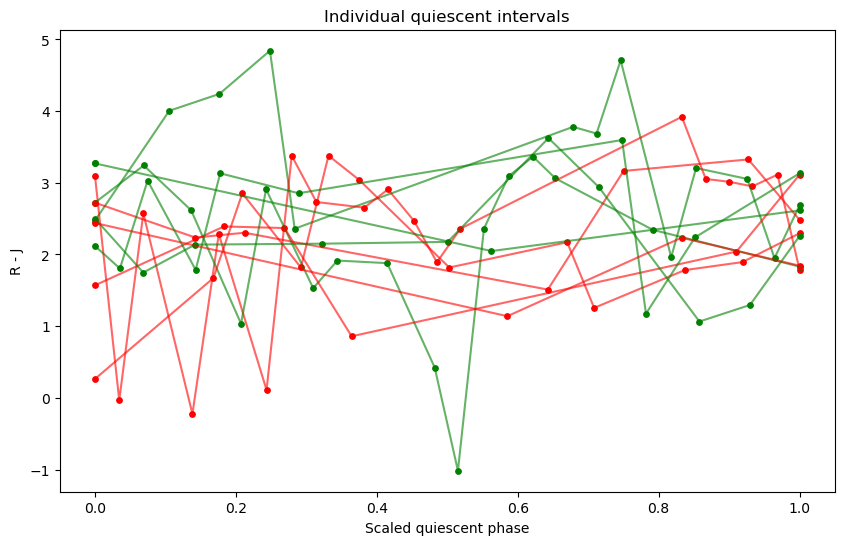

In [3]:
records = []

for qnum, ((start, end), follow_label) in enumerate(
    zip(quiescent_intervals, q_labels),
    start=1
):

    seg = RJ[
        (RJ["MJD_R"] >= start) &
        (RJ["MJD_R"] <= end)
    ].copy()

    if len(seg) < 2:
        continue

    t0 = seg["MJD_R"].min()
    t1 = seg["MJD_R"].max()

    if t1 <= t0:
        continue

    seg["scaled_phase"] = (
        (seg["MJD_R"] - t0) /
        (t1 - t0)
    )

    seg["aligned_end"] = (
        (seg["MJD_R"] - t1)
    )

    seg["Q"] = qnum
    seg["follow_label"] = follow_label

    records.append(seg)

color_df = pd.concat(records, ignore_index=True)

plt.figure(figsize=(10,6))

for qnum, seg in color_df.groupby("Q"):

    lab = seg["follow_label"].iloc[0]

    plt.plot(
        seg["scaled_phase"],
        seg["R_minus_J"],
        color=label_colors[lab],
        alpha=0.6
    )

    plt.scatter(
        seg["scaled_phase"],
        seg["R_minus_J"],
        color=label_colors[lab],
        s=15
    )

plt.xlabel("Scaled quiescent phase")
plt.ylabel("R - J")
plt.title("Individual quiescent intervals")
plt.show()

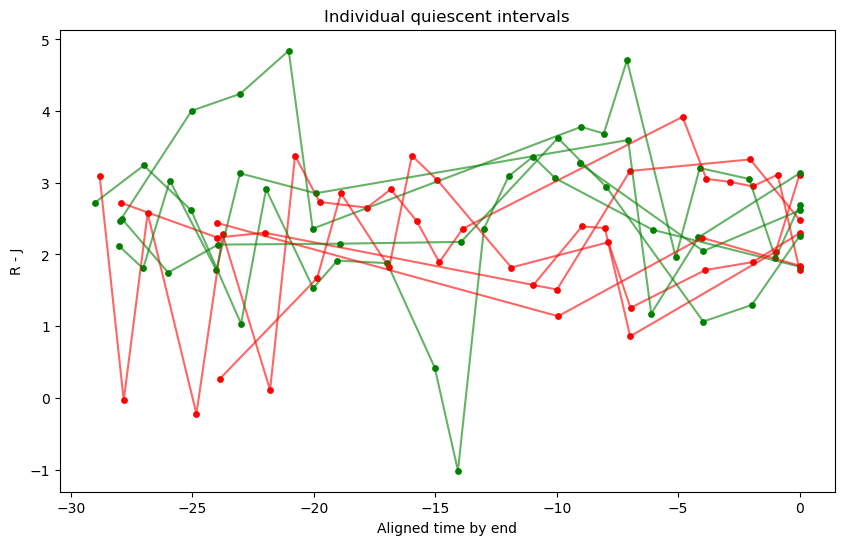

In [4]:
plt.figure(figsize=(10,6))

for qnum, seg in color_df.groupby("Q"):

    lab = seg["follow_label"].iloc[0]

    plt.plot(
        seg["aligned_end"],
        seg["R_minus_J"],
        color=label_colors[lab],
        alpha=0.6
    )

    plt.scatter(
        seg["aligned_end"],
        seg["R_minus_J"],
        color=label_colors[lab],
        s=15
    )

plt.xlabel("Aligned time by end")
plt.ylabel("R - J")
plt.title("Individual quiescent intervals")
plt.show()

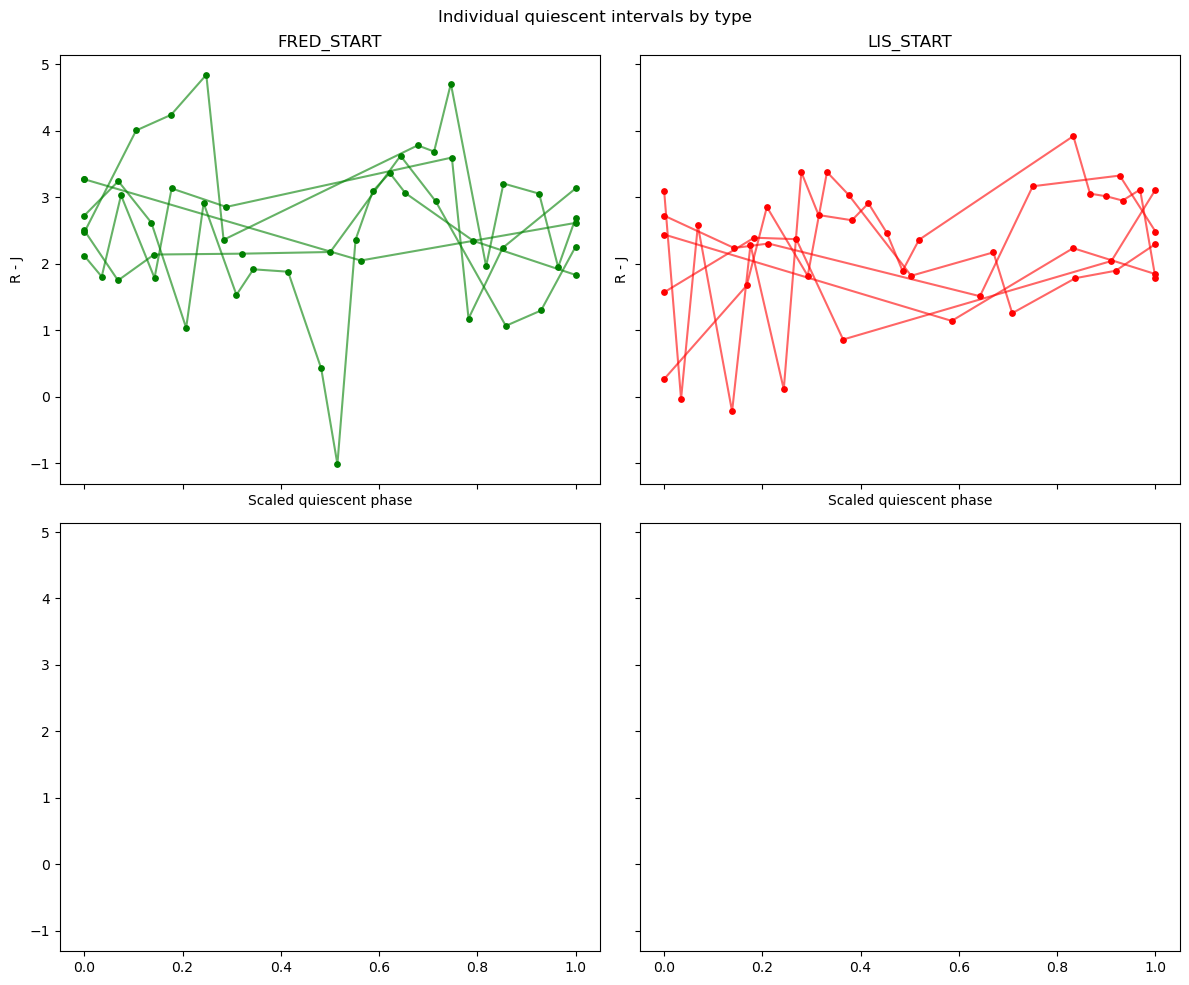

In [5]:
types = sorted(color_df["follow_label"].unique())

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lab in zip(axes, types):

    subset = color_df[color_df["follow_label"] == lab]

    for qnum, seg in subset.groupby("Q"):

        ax.plot(
            seg["scaled_phase"],
            seg["R_minus_J"],
            color=label_colors[lab],
            alpha=0.6
        )

        ax.scatter(
            seg["scaled_phase"],
            seg["R_minus_J"],
            color=label_colors[lab],
            s=15
        )

    ax.set_title(lab)
    ax.set_xlabel("Scaled quiescent phase")
    ax.set_ylabel("R - J")

plt.suptitle("Individual quiescent intervals by type")
plt.tight_layout()
plt.show()

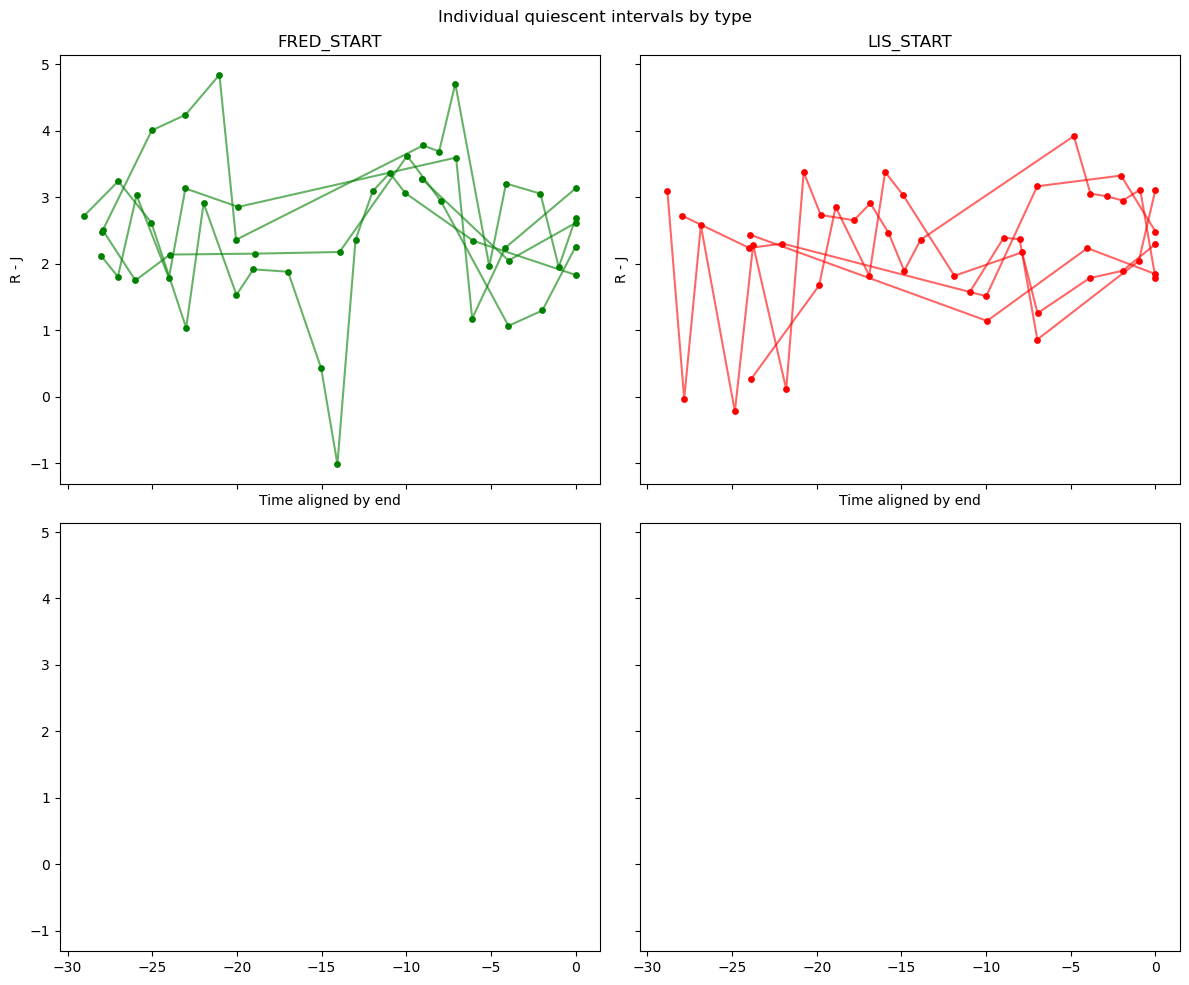

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lab in zip(axes, types):

    subset = color_df[color_df["follow_label"] == lab]

    for qnum, seg in subset.groupby("Q"):

        ax.plot(
            seg["aligned_end"],
            seg["R_minus_J"],
            color=label_colors[lab],
            alpha=0.6
        )

        ax.scatter(
            seg["aligned_end"],
            seg["R_minus_J"],
            color=label_colors[lab],
            s=15
        )

    ax.set_title(lab)
    ax.set_xlabel("Time aligned by end")
    ax.set_ylabel("R - J")

plt.suptitle("Individual quiescent intervals by type")
plt.tight_layout()
plt.show()

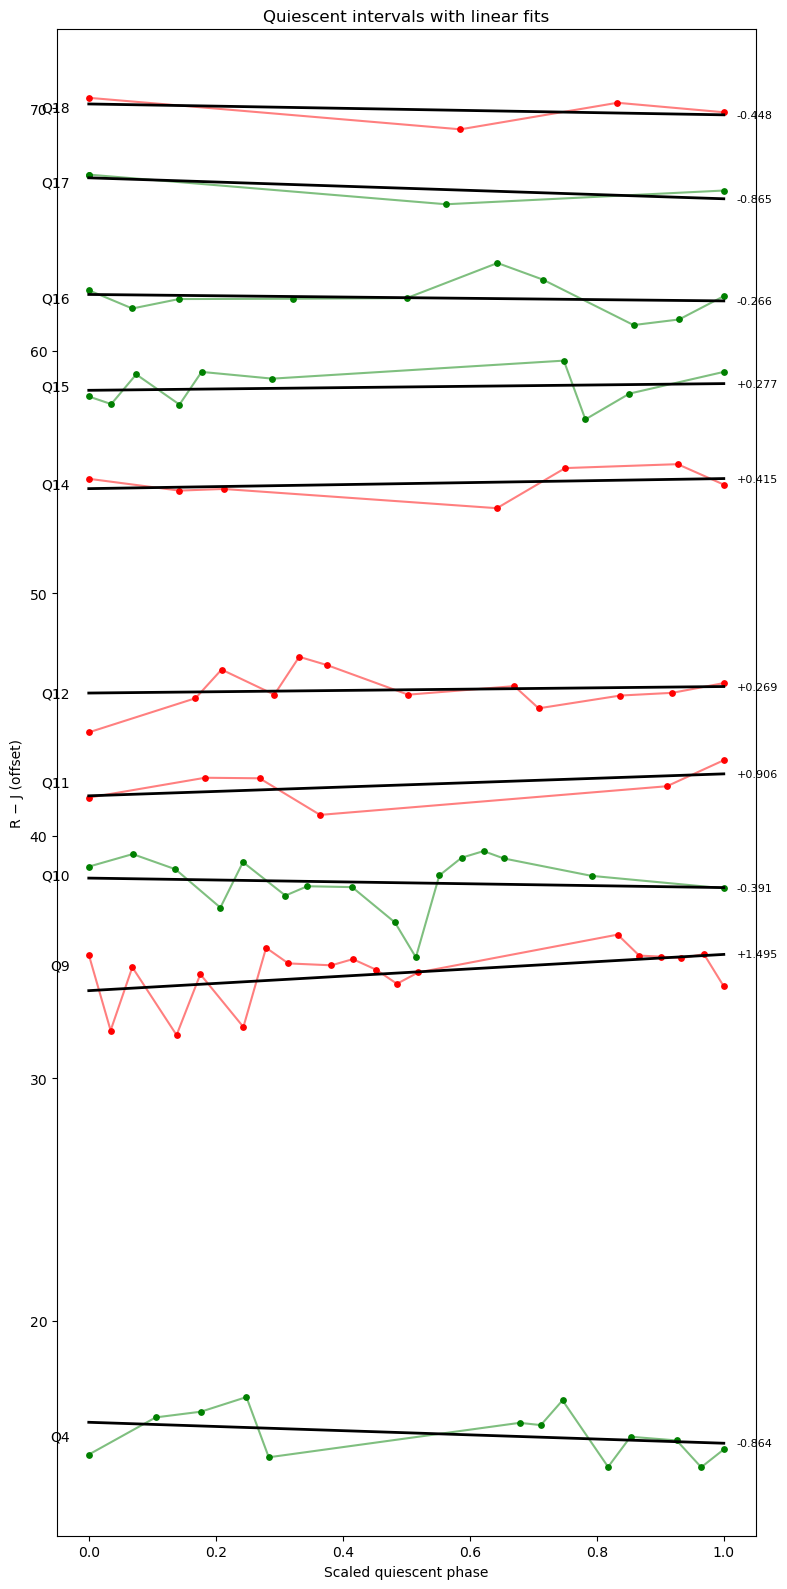

In [7]:
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(8, 16))

offset = 4

for qnum, seg in color_df.groupby("Q"):

    y = seg["R_minus_J"] + (qnum - 1) * offset
    x = seg["scaled_phase"].values

    lab = seg["follow_label"].iloc[0]

    # data
    ax.plot(x, y, color=label_colors[lab], alpha=0.5)
    ax.scatter(x, y, color=label_colors[lab], s=15)

    # fit
    slope, intercept, r, p, stderr = linregress(x, y)

    xfit = np.array([0, 1])
    yfit = intercept + slope * xfit

    ax.plot(
        xfit,
        yfit,
        color="k",
        lw=2
    )

    # label interval number
    ax.text(
        -0.03,
        np.nanmedian(y),
        f"Q{qnum}",
        ha="right",
        va="center"
    )

    # label slope near end of fit
    ax.text(
        1.02,
        intercept + slope,
        f"{slope:+.3f}",
        fontsize=8,
        va="center"
    )

ax.set_xlabel("Scaled quiescent phase")
ax.set_ylabel("R − J (offset)")
ax.set_title("Quiescent intervals with linear fits")

plt.tight_layout()
plt.show()

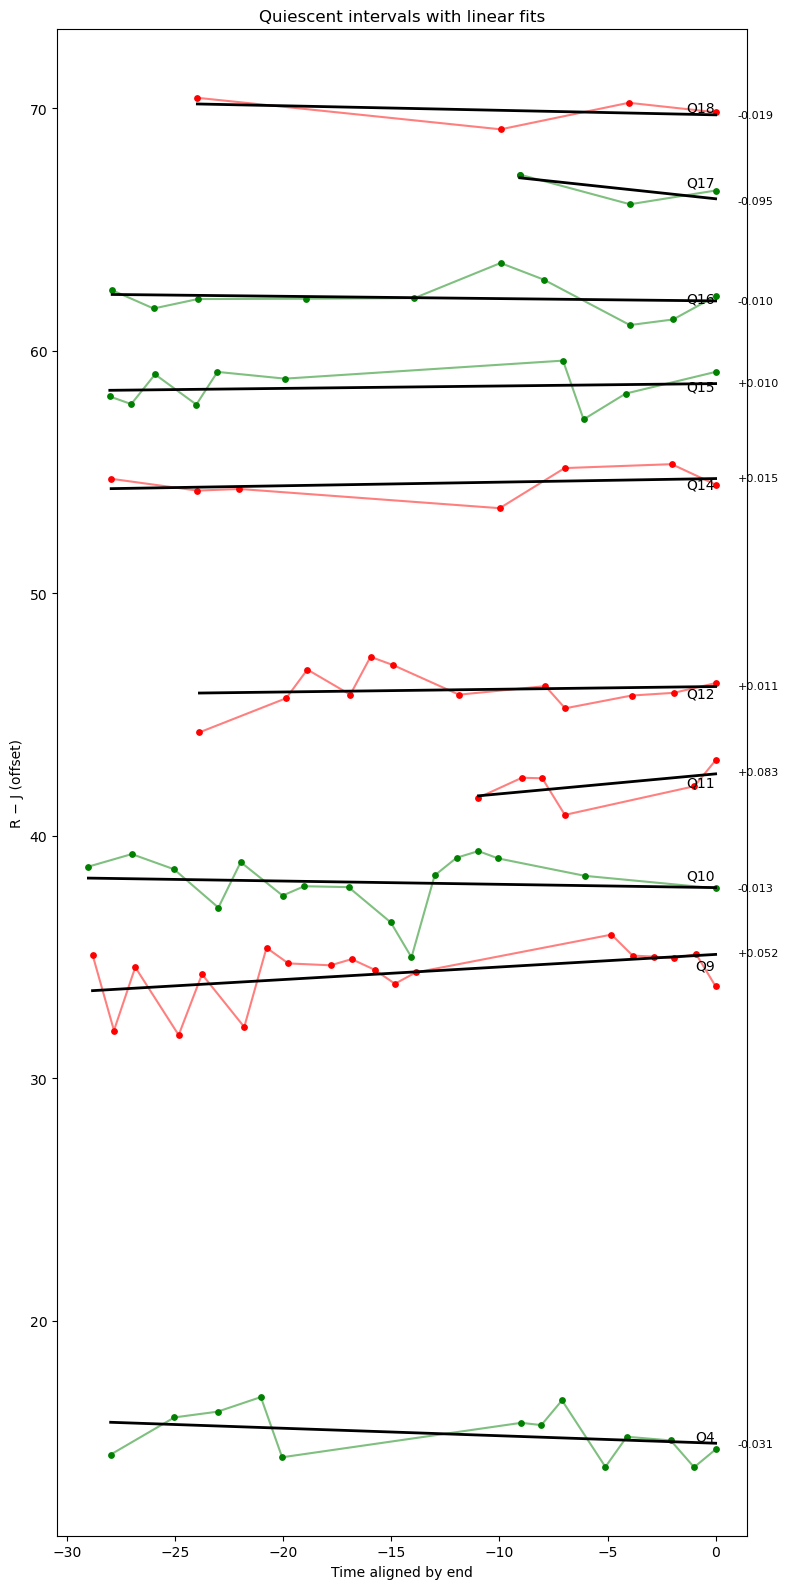

In [8]:

fig, ax = plt.subplots(figsize=(8, 16))

offset = 4

for qnum, seg in color_df.groupby("Q"):

    y = seg["R_minus_J"] + (qnum - 1) * offset
    x = seg["aligned_end"].values

    lab = seg["follow_label"].iloc[0]

    # data
    ax.plot(x, y, color=label_colors[lab], alpha=0.5)
    ax.scatter(x, y, color=label_colors[lab], s=15)

    # fit
    slope, intercept, r, p, stderr = linregress(x, y)

    xfit = np.array([np.min(x), 0])
    yfit = intercept + slope * xfit

    ax.plot(
        xfit,
        yfit,
        color="k",
        lw=2
    )

    # label interval number
    ax.text(
        -0.03,
        np.nanmedian(y),
        f"Q{qnum}",
        ha="right",
        va="center"
    )

    # label slope near end of fit
    ax.text(
        1.02,
        intercept + slope,
        f"{slope:+.3f}",
        fontsize=8,
        va="center"
    )

ax.set_xlabel("Time aligned by end")
ax.set_ylabel("R − J (offset)")
ax.set_title("Quiescent intervals with linear fits")

plt.tight_layout()
plt.show()

In [9]:
slopes = []

for qnum, seg in color_df.groupby("Q"):

    slope, intercept, r, p, stderr = linregress(
        seg["scaled_phase"],
        seg["R_minus_J"]
    )

    slopes.append({
        "Q": qnum,
        "type": seg["follow_label"].iloc[0],
        "slope": slope,
        "stderr": stderr,
        "r2": r**2,
        "p": p
    })

slopes_df = pd.DataFrame(slopes)

In [10]:
slopes2 = []

for qnum, seg in color_df.groupby("Q"):

    slope, intercept, r, p, stderr = linregress(
        seg["aligned_end"],
        seg["R_minus_J"]
    )

    slopes2.append({
        "Q": qnum,
        "type": seg["follow_label"].iloc[0],
        "slope": slope,
        "stderr": stderr,
        "r2": r**2,
        "p": p
    })

slopes2_df = pd.DataFrame(slopes2)

/tmp/ipykernel_1372345/37151043.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


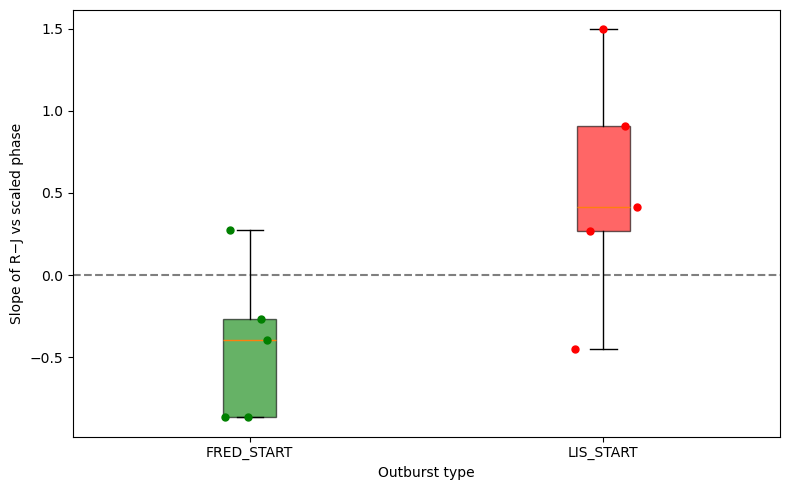

In [11]:

fig, ax = plt.subplots(figsize=(8, 5))
order = list(label_colors.keys())

types = [
    t for t in order
    if t in slopes_df["type"].unique()
]

data = [
    slopes_df.loc[slopes_df["type"] == t, "slope"]
    for t in types
]

bp = ax.boxplot(
    data,
    labels=types,
    patch_artist=True
)

for box, t in zip(bp["boxes"], types):
    box.set_facecolor(label_colors[t])
    box.set_alpha(0.6)

# show individual points too
for i, t in enumerate(types, start=1):

    y = slopes_df.loc[slopes_df["type"] == t, "slope"]

    x = np.random.normal(i, 0.05, len(y))

    ax.scatter(
        x,
        y,
        color=label_colors[t],
        s=25,
        zorder=3
    )

ax.axhline(0, color="k", ls="--", alpha=0.5)

ax.set_ylabel("Slope of R−J vs scaled phase")
ax.set_xlabel("Outburst type")

plt.tight_layout()
plt.savefig('/home/kmc249/Downloads/color_slope_30day.png', dpi=300)
plt.show()

/tmp/ipykernel_1372345/1740367882.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


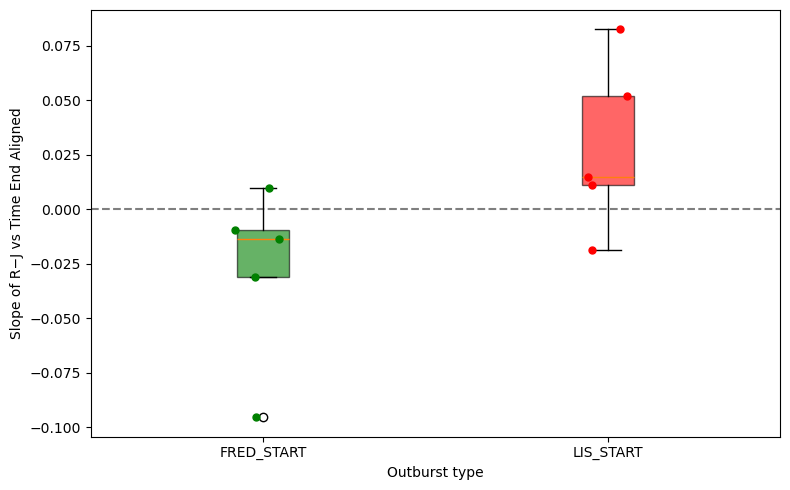

In [12]:

fig, ax = plt.subplots(figsize=(8, 5))
order = list(label_colors.keys())

types = [
    t for t in order
    if t in slopes2_df["type"].unique()
]

data = [
    slopes2_df.loc[slopes2_df["type"] == t, "slope"]
    for t in types
]

bp = ax.boxplot(
    data,
    labels=types,
    patch_artist=True
)

for box, t in zip(bp["boxes"], types):
    box.set_facecolor(label_colors[t])
    box.set_alpha(0.6)

# show individual points too
for i, t in enumerate(types, start=1):

    y = slopes2_df.loc[slopes2_df["type"] == t, "slope"]

    x = np.random.normal(i, 0.05, len(y))

    ax.scatter(
        x,
        y,
        color=label_colors[t],
        s=25,
        zorder=3
    )

ax.axhline(0, color="k", ls="--", alpha=0.5)

ax.set_ylabel("Slope of R−J vs Time End Aligned")
ax.set_xlabel("Outburst type")

plt.tight_layout()
plt.show()

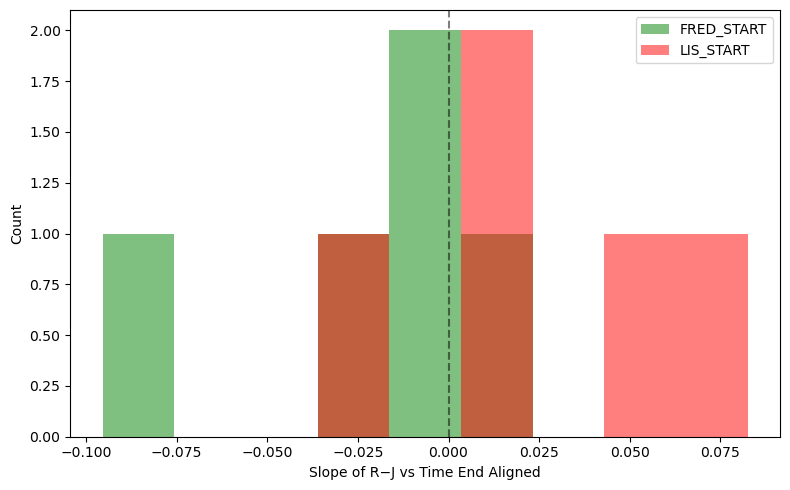

In [13]:
if leadup_only_run:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    bins = np.linspace(
        slopes2_df["slope"].min(),
        slopes2_df["slope"].max(),
        10  # adjust as needed
    )
    
    for t in types:
        y = slopes2_df.loc[slopes2_df["type"] == t, "slope"]
    
        ax.hist(
            y,
            bins=bins,
            alpha=0.5,
            color=label_colors[t],
            label=t
        )
    
    ax.axvline(0, color='k', ls='--', alpha=0.5)
    ax.set_xlabel("Slope of R−J vs Time End Aligned")
    ax.set_ylabel("Count")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

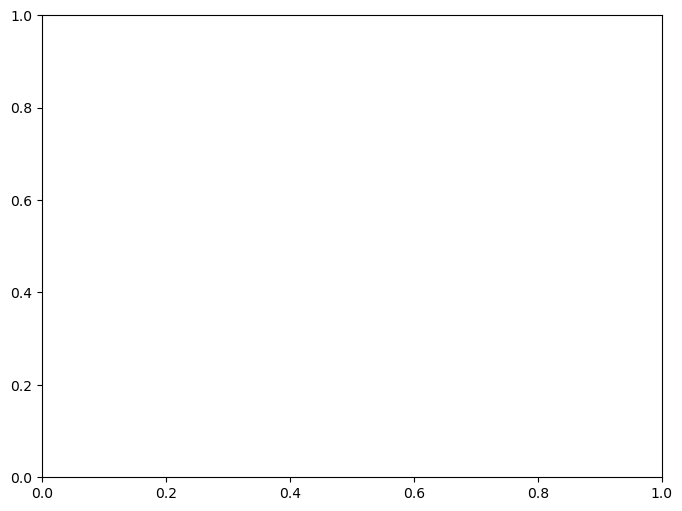

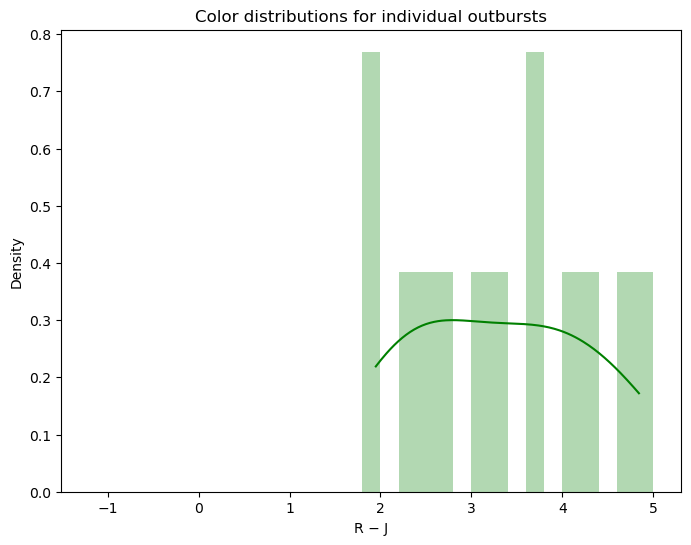

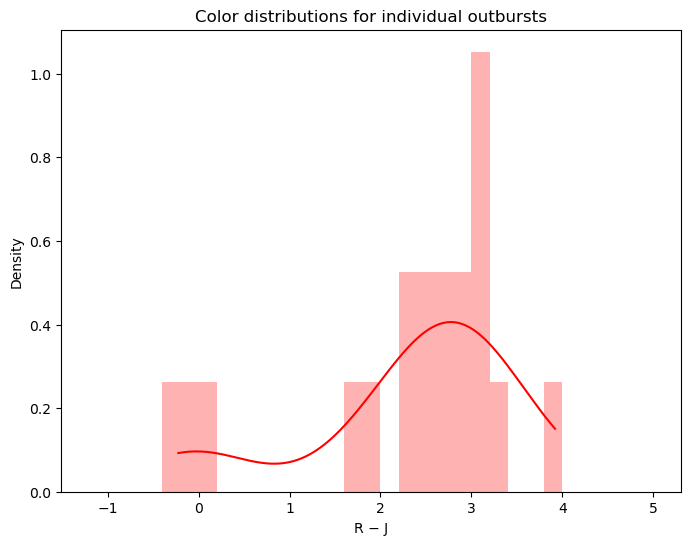

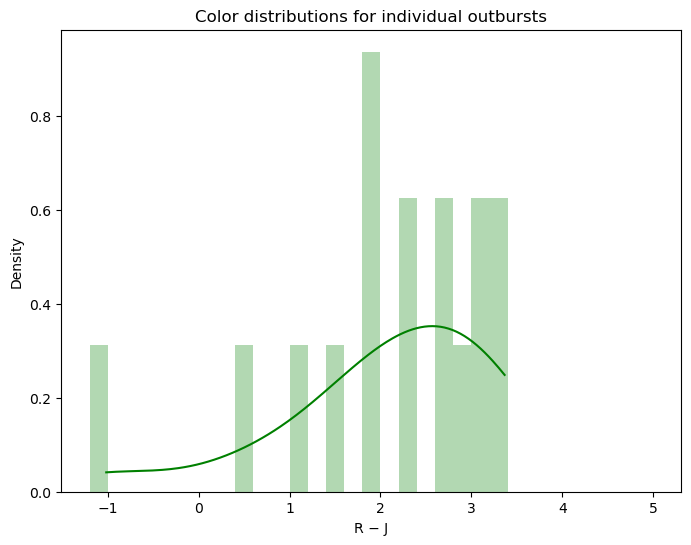

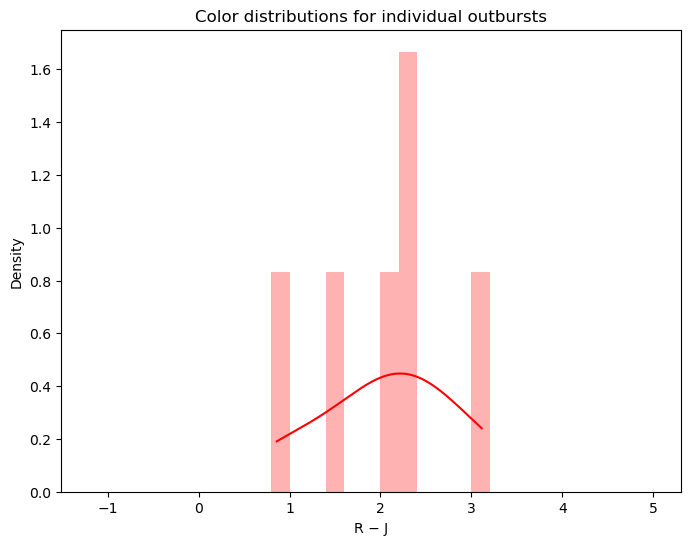

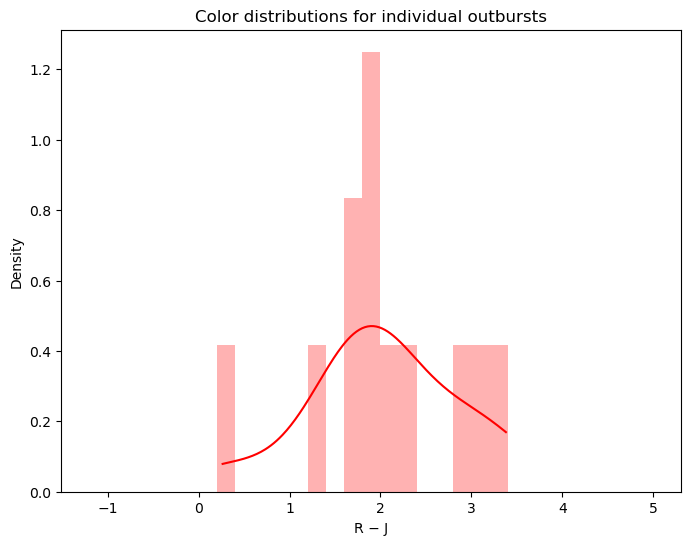

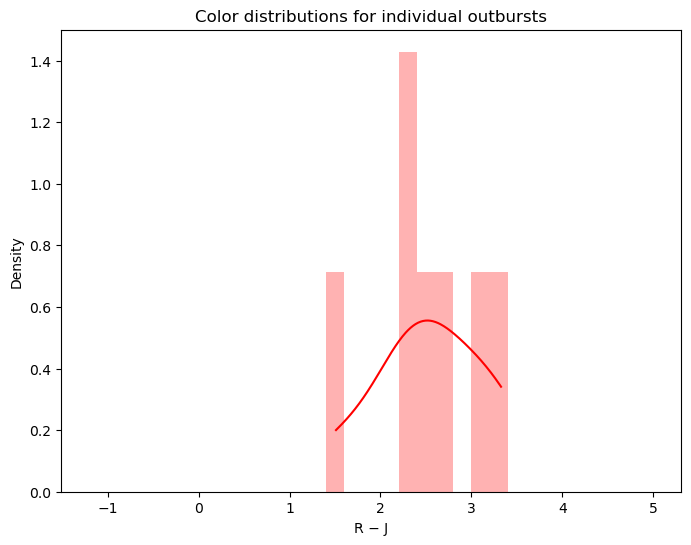

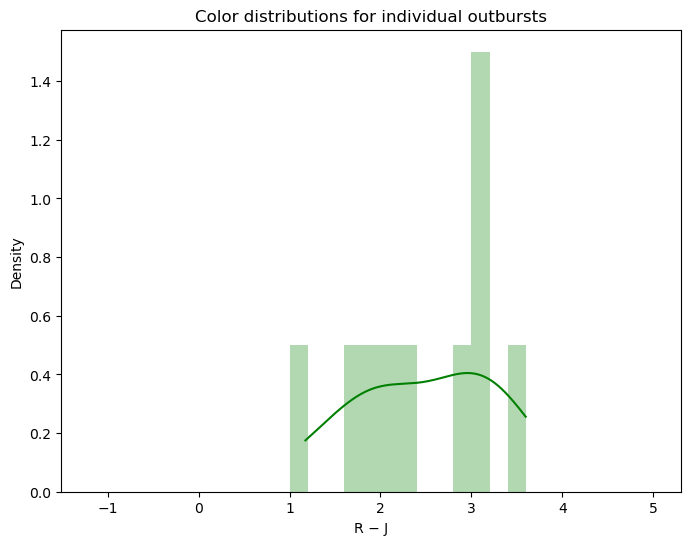

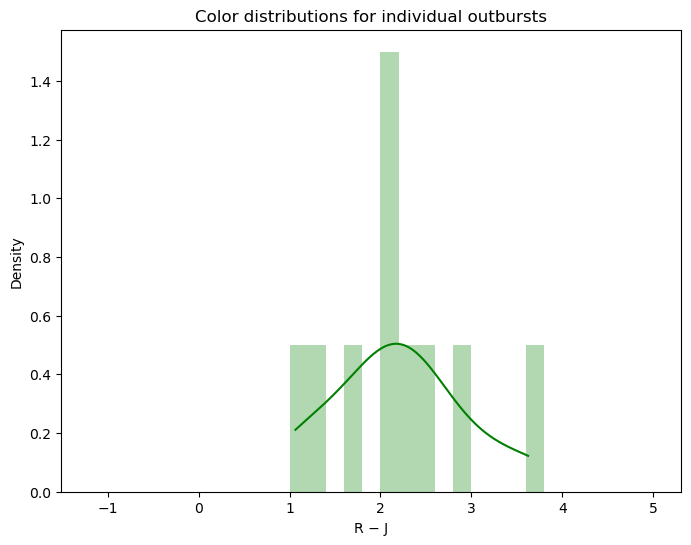

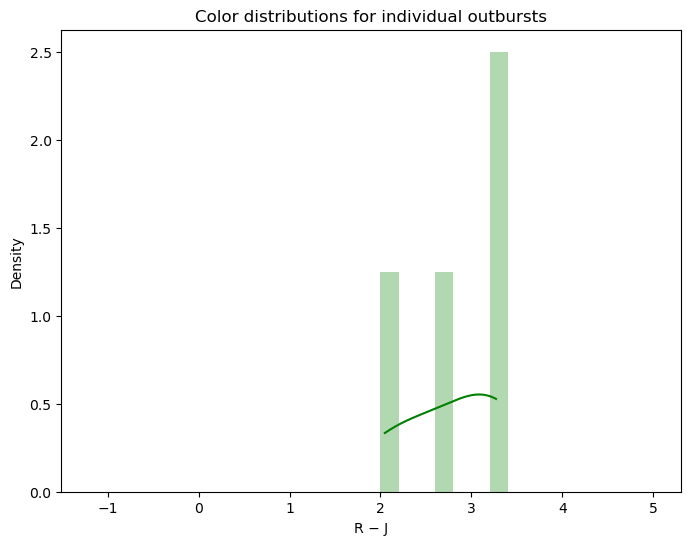

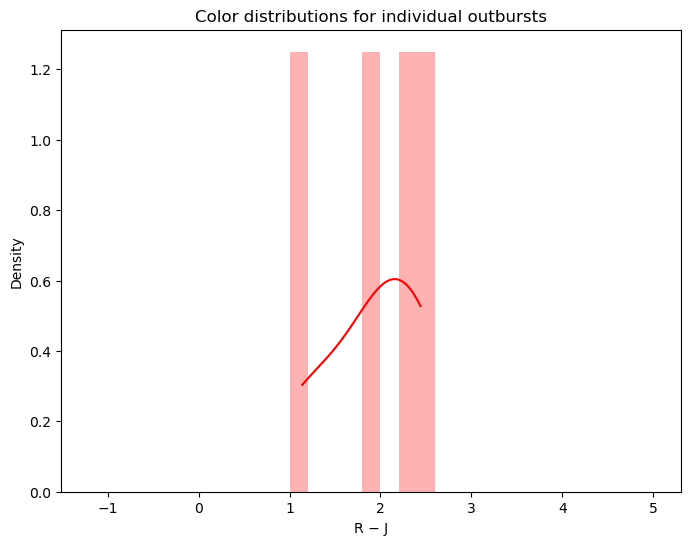

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
binwidth = 0.2

xmin = color_df["R_minus_J"].min()
xmax = color_df["R_minus_J"].max()

bins = np.arange(
    np.floor(xmin/binwidth)*binwidth,
    np.ceil(xmax/binwidth)*binwidth + binwidth,
    binwidth
)
for qnum, seg in color_df.groupby("Q"):
    fig, ax = plt.subplots(figsize=(8, 6))
    label = seg["follow_label"].iloc[0]

    sns.histplot(
        seg["R_minus_J"],
        bins=bins,
        stat="density",      # makes different sample sizes comparable
        element="step",
        fill=True,
        color=label_colors[label],
        alpha=0.3,
        linewidth=0,
        ax=ax,
        kde=True,
        label=f"Q{qnum}"     # optional, may clutter legend
    )
    

    ax.set_xlabel("R − J")
    ax.set_ylabel("Density")
    ax.set_title("Color distributions for individual outbursts")
    
    plt.show()

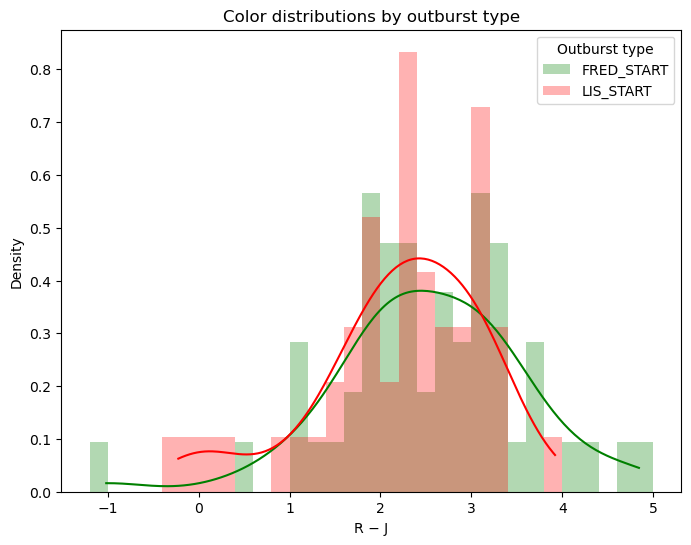

In [15]:
binwidth = 0.2

xmin = color_df["R_minus_J"].min()
xmax = color_df["R_minus_J"].max()

bins = np.arange(
    np.floor(xmin/binwidth)*binwidth,
    np.ceil(xmax/binwidth)*binwidth + binwidth,
    binwidth
)

fig, ax = plt.subplots(figsize=(8, 6))

for label, seg in color_df.groupby("follow_label"):

    sns.histplot(
        seg["R_minus_J"],
        bins=bins,
        stat="density",
        element="step",
        fill=True,
        alpha=0.3,
        color=label_colors[label],
        ax=ax,
        linewidth=0,
        label=label,
        kde=True,
    )

ax.set_xlabel("R − J")
ax.set_ylabel("Density")
ax.set_title("Color distributions by outburst type")
ax.legend(title="Outburst type")
plt.savefig('/home/kmc249/Downloads/quiescenthisto.png', dpi=300)
plt.show()

In [16]:

outburst_summary = (
    color_df.groupby(["Q", "follow_label"])
    .agg(
        median_color=("R_minus_J", "median"),
        mean_color=("R_minus_J", "mean")
    )
    .reset_index()
)
'''
from scipy.stats import kruskal

groups = [
    g["median_color"].values
    for _, g in outburst_summary.groupby("follow_label")
]

H, p = kruskal(*groups)

print(H, p)
'''

'\nfrom scipy.stats import kruskal\n\ngroups = [\n    g["median_color"].values\n    for _, g in outburst_summary.groupby("follow_label")\n]\n\nH, p = kruskal(*groups)\n\nprint(H, p)\n'

In [17]:

from scipy.stats import ks_2samp

from scipy.stats import mannwhitneyu
if leadup_only_run:
    g1 = outburst_summary.loc[
        outburst_summary["follow_label"] == "LIS_START",
        "median_color"
    ]
    
    g2 = outburst_summary.loc[
        outburst_summary["follow_label"] == "FRED_START",
        "median_color"
    ]
    
    u, p = mannwhitneyu(g1, g2, alternative="two-sided")
    
    print(p)
    
    D, p = ks_2samp(g1, g2)
    
    print(p)

    
else:
    g1 = outburst_summary.loc[
        outburst_summary["follow_label"] == "ONLY_LIS",
        "median_color"
    ]
    
    g2 = outburst_summary.loc[
        outburst_summary["follow_label"] == "ONLY_FRED",
        "median_color"
    ]
    
    u, p = mannwhitneyu(g1, g2, alternative="two-sided")
    
    print(p)
    
    D, p = ks_2samp(g1, g2)
    
    print(p)


0.2222222222222222
0.873015873015873


/tmp/ipykernel_1372345/3239421789.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


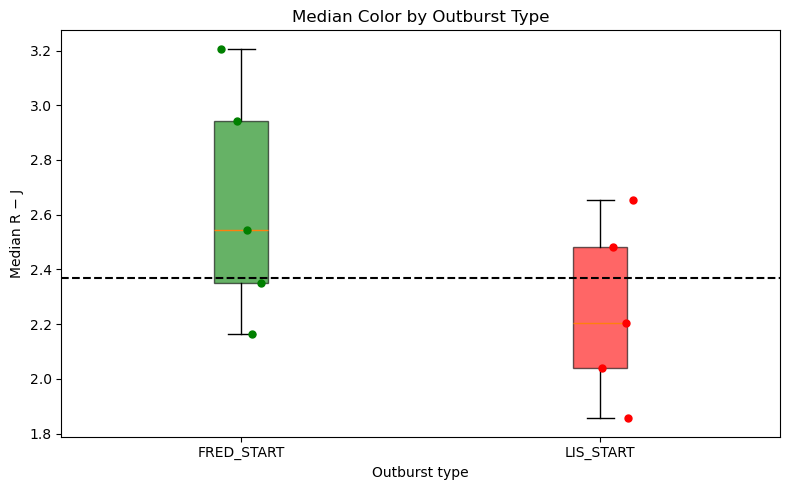

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

order = list(label_colors.keys())

types = [
    t for t in order
    if t in outburst_summary["follow_label"].unique()
]

data = [
    outburst_summary.loc[
        outburst_summary["follow_label"] == t,
        "median_color"
    ]
    for t in types
]

bp = ax.boxplot(
    data,
    labels=types,
    patch_artist=True
)

for box, t in zip(bp["boxes"], types):
    box.set_facecolor(label_colors[t])
    box.set_alpha(0.6)

# show individual median-color values
for i, t in enumerate(types, start=1):

    y = outburst_summary.loc[
        outburst_summary["follow_label"] == t,
        "median_color"
    ]

    x = np.random.normal(i, 0.05, len(y))

    ax.scatter(
        x,
        y,
        color=label_colors[t],
        s=25,
        zorder=3
    )
overall_median = overall_median = color_df["R_minus_J"].median()

ax.axhline(
    overall_median,
    color="k",
    ls="--",
    lw=1.5,
    label=f"Overall median = {overall_median:.2f}"
)
ax.set_ylabel("Median R − J")
ax.set_xlabel("Outburst type")
ax.set_title("Median Color by Outburst Type")

plt.tight_layout()
plt.show()

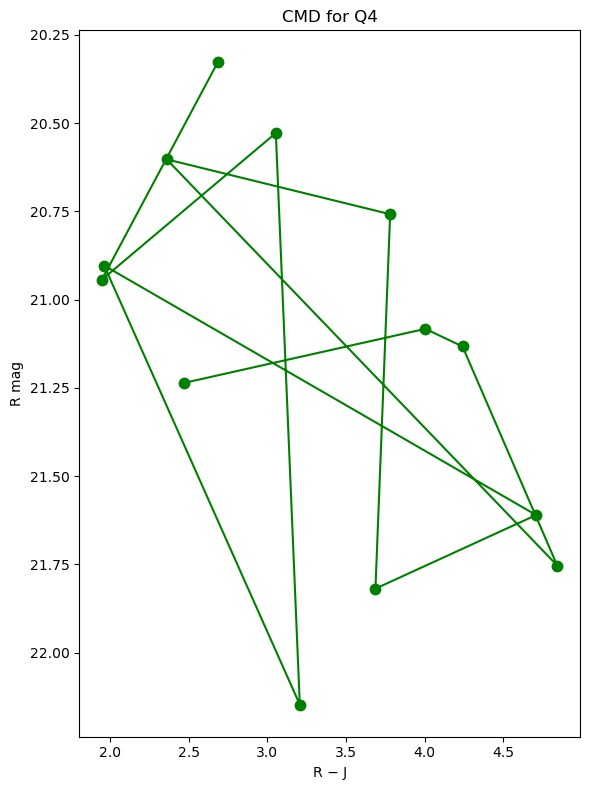

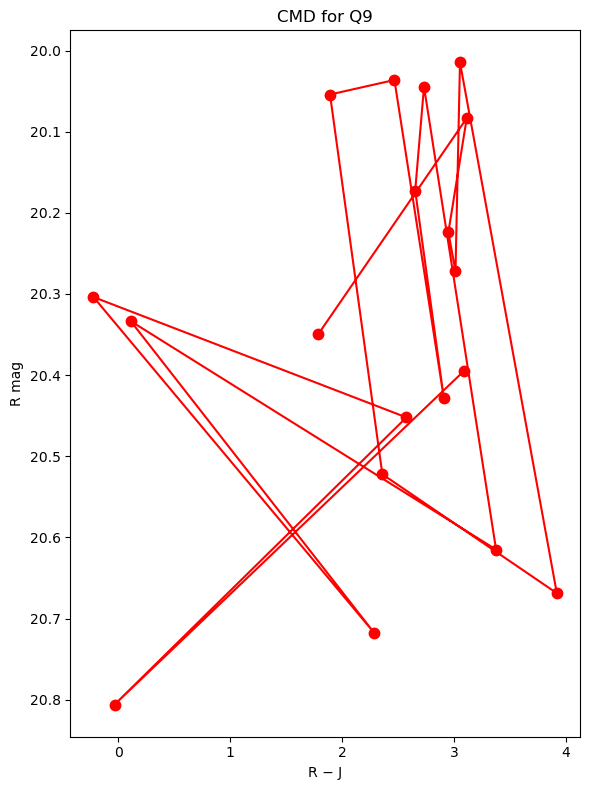

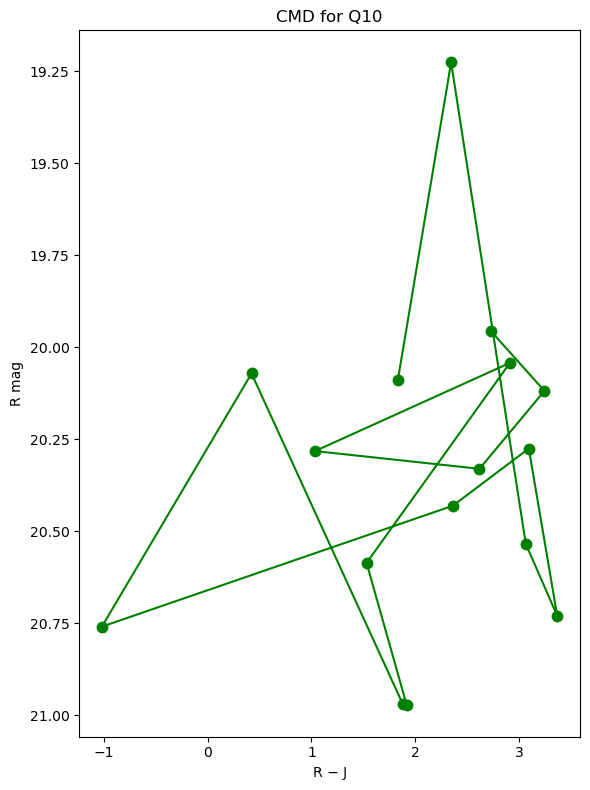

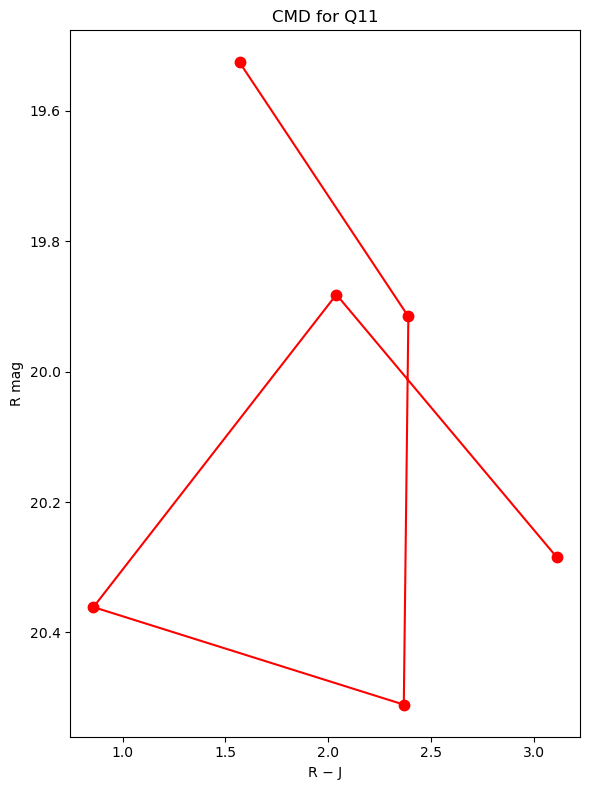

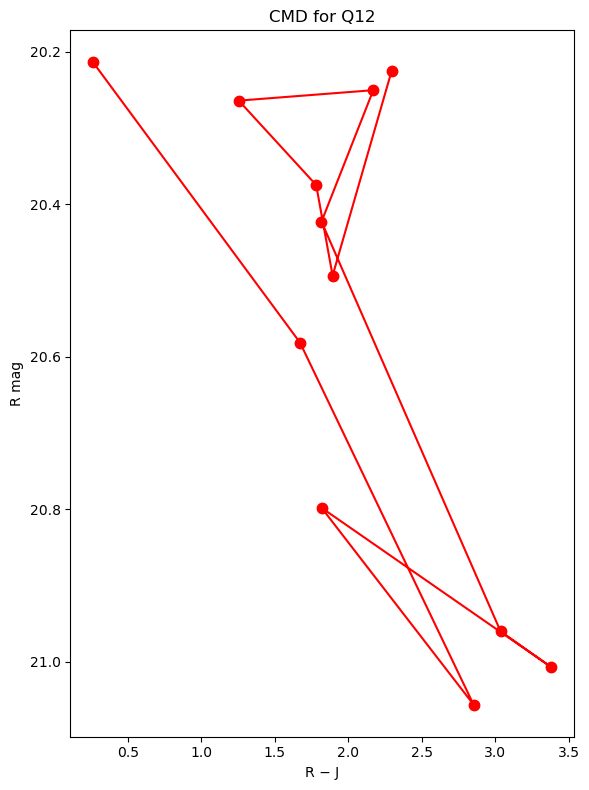

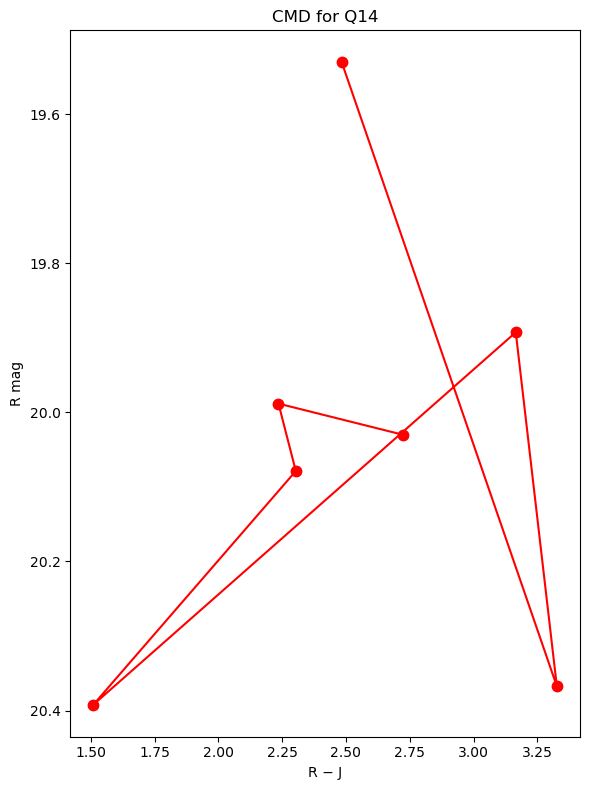

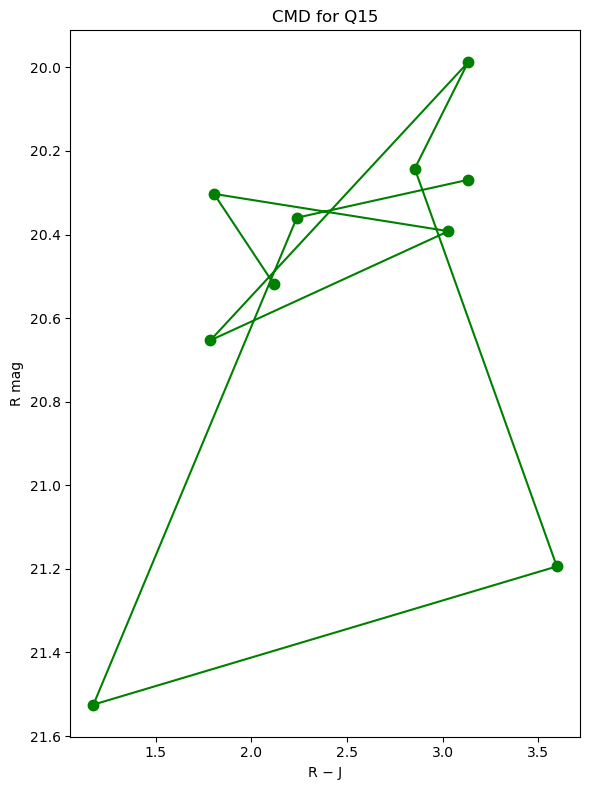

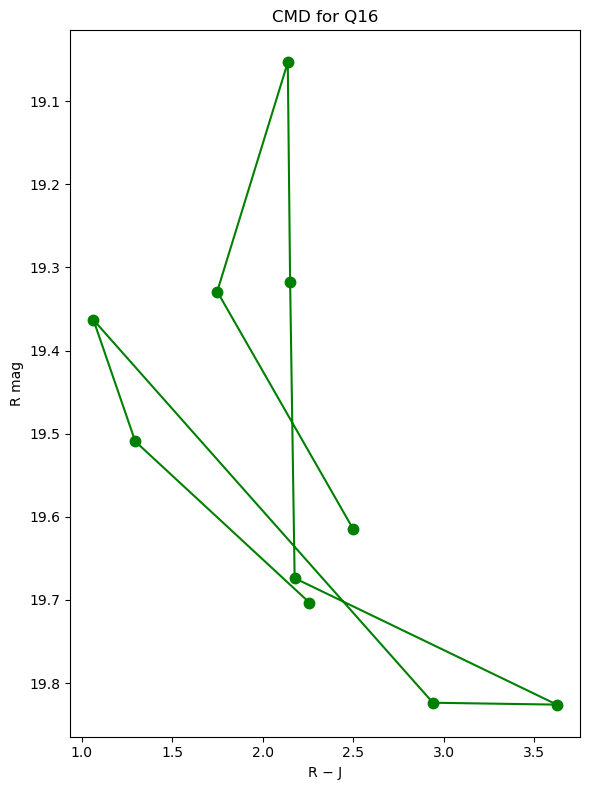

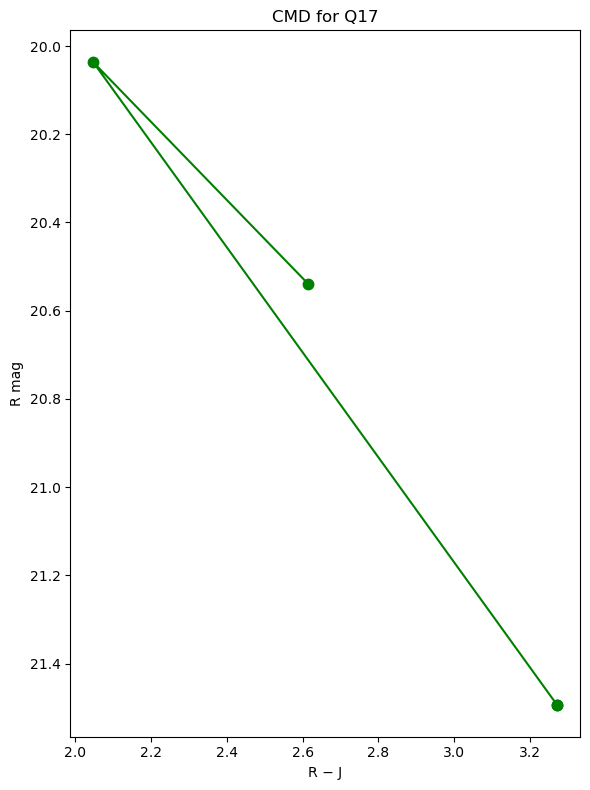

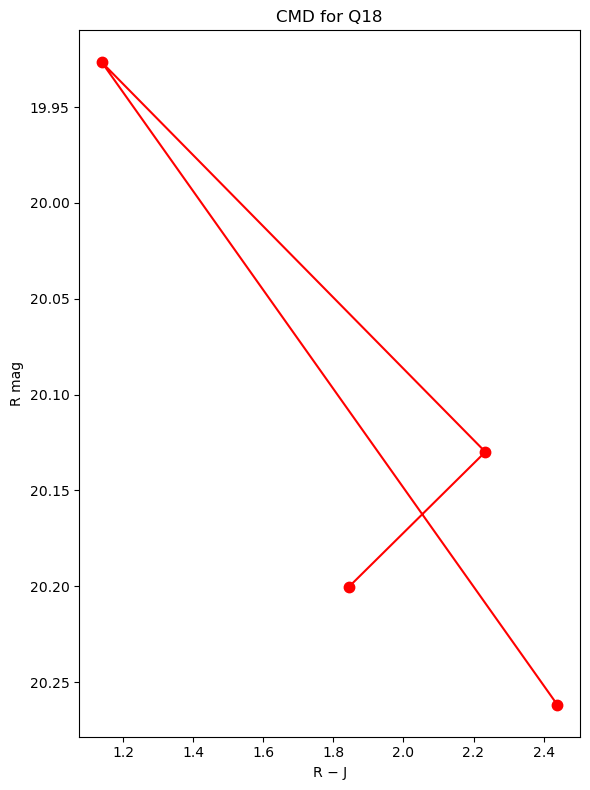

In [19]:
#CMDs

for qnum, seg in color_df.groupby("Q"):
    plt.figure(figsize=(6,8))
    x = seg["R_minus_J"]
    y = seg["mag_shifted_R"].values
    yerr = seg["mag_shifted_err_R"].values
    xerr=np.sqrt(yerr**2+seg["mag_shifted_err_J"].values**2)

    lab = seg["follow_label"].iloc[0]

    # data
    plt.errorbar(x, y, yerr=0, xerr=0, color=label_colors[lab], markersize=15, fmt='.-')


    plt.title(f"CMD for Q{qnum}")
    plt.xlabel("R − J")
    plt.ylabel("R mag")
    plt.gca().invert_yaxis()
    
    plt.tight_layout()
    plt.show()

In [20]:
if fullrun:
    from scipy.optimize import least_squares
    def broken_line(x, m1, m2, split, y0):
        return np.where(
            x < split,
            m1 * (x - split) + y0,
            m2 * (x - split) + y0
        )
    def residuals(params, x, y, yerr, xerr):
        m1, m2, split,b = params
        
        model = broken_line(x, m1, b, m2, split)
        
        effective_err = np.sqrt(yerr**2 + (m1 * xerr)**2)
        return (y - model) / effective_err
    all_x=[]
    all_y=[]
    all_yerr=[]
    all_xerr=[]
    plt.figure(figsize=(10,8))
    for qnum, seg in color_df.groupby("Q"):
    
        x = seg["R_minus_J"]
        y = seg["mag_shifted_R"].values
        yerr = seg["mag_shifted_err_R"].values
        xerr=np.sqrt(yerr**2+seg["mag_shifted_err_J"].values**2)
    
        mask = xerr < 1
    
        xignore = x[~mask]
        yignore = y[~mask]
        yerrignore = yerr[~mask]
        xerrignore = xerr[~mask]
        
        x = x[mask]
        y = y[mask]
        yerr = yerr[mask]
        xerr = xerr[mask]
    
        lab = seg["follow_label"].iloc[0]
        all_x.extend(x.to_numpy())
        all_y.extend(y)
        all_yerr.extend(yerr)
        all_xerr.extend(xerr)
        

        # data
        plt.errorbar(x, y, yerr=yerr, xerr=xerr, color=label_colors[lab], markersize=15, fmt='.', alpha=0.75)
    
        plt.errorbar(
            xignore, yignore,
            yerr=yerrignore,
            xerr=xerrignore,
            fmt='.',
            color='gray',
            alpha=0.2,
            markersize=8
        )

    x = np.array(all_x)
    y = np.array(all_y)
    yerr = np.array(all_yerr)
    xerr = np.array(all_xerr)
    
    # initial guess (VERY important)
    p0 = [2.5,  1.0, 2.1, 30]   # m1, m2, split, b
    
    # bounds (force negative slopes if needed)
    lower = [0,  0, 1,-np.inf,]
    upper = [np.inf, np.inf, 4, np.inf,]
    
    result = least_squares(
        residuals,
        p0,
        bounds=(lower, upper),
        args=(x, y, yerr, xerr)
    )
    
    popt = result.x
    print("fit params:", popt)
    xplot=np.linspace(-2,7,100)
    yplot=broken_line(xplot, *popt)
    plt.plot(xplot, yplot, zorder=67,label=f'y={popt[0]:.2f}x+{popt[3]:.2f} and other slope {popt[2]:.2f}, plus split={popt[2]}', color='k')
    #plt.gca().invert_yaxis()
    plt.xlim(-5,9)
    plt.ylim(24,15)
    plt.title("CMD")
    plt.xlabel("R − J")
    plt.ylabel("R mag")
    plt.legend()
    plt.axvline(2, zorder=230)
    plt.tight_layout()
    plt.show()



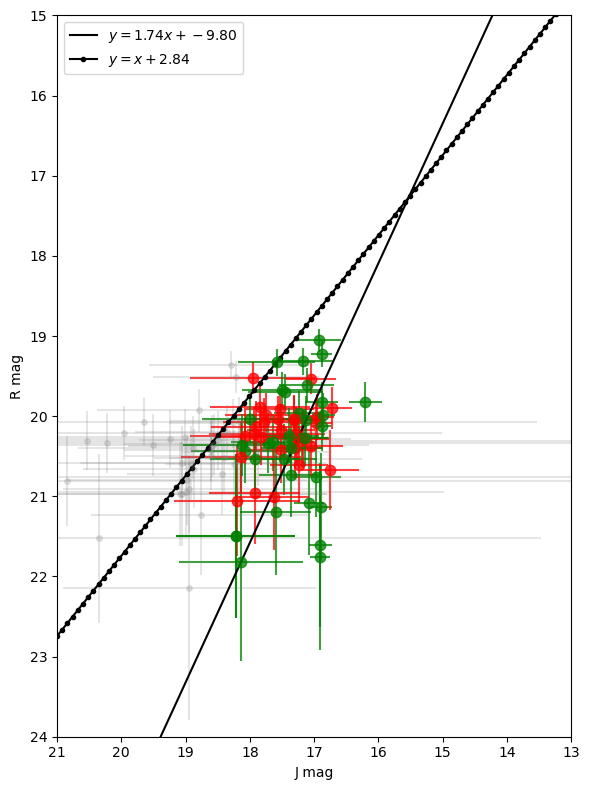

In [21]:
#Real best fit
from scipy.odr import ODR, Model, RealData

def line(B, x):
    return B[0] * x + B[1]

def yxline(B, x):
    return x+B[0]

all_x = []
all_y = []
all_xerr = []
all_yerr = []

plt.figure(figsize=(6, 8))

for qnum, seg in color_df.groupby("Q"):

    x = seg["mag_shifted_J"].values
    y = seg["mag_shifted_R"].values
    yerr = seg["mag_shifted_err_R"].values
    xerr =seg["mag_shifted_err_J"].values

    mask = xerr < 1

    xignore = x[~mask]
    yignore = y[~mask]
    xerrignore = xerr[~mask]
    yerrignore = yerr[~mask]

    x = x[mask]
    y = y[mask]
    xerr = xerr[mask]
    yerr = yerr[mask]

    lab = seg["follow_label"].iloc[0]

    all_x.extend(x)
    all_y.extend(y)
    all_xerr.extend(xerr)
    all_yerr.extend(yerr)

    plt.errorbar(
        x, y,
        xerr=xerr,
        yerr=yerr,
        fmt='.',
        color=label_colors[lab],
        alpha=0.75,
        markersize=15
    )

    plt.errorbar(
        xignore, yignore,
        xerr=xerrignore,
        yerr=yerrignore,
        fmt='.',
        color='gray',
        alpha=0.2,
        markersize=8
    )

# Convert to arrays
all_x = np.array(all_x)
all_y = np.array(all_y)
all_xerr = np.array(all_xerr)
all_yerr = np.array(all_yerr)

# ODR fit
model = Model(line)
yxmodel = Model(yxline)
data = RealData(
    all_x,
    all_y,
    sx=all_xerr,
    sy=all_yerr
)

odr = ODR(data, model, beta0=[-7/8, 18])
output = odr.run()
odr2 = ODR(data, yxmodel, beta0=[18])
output2 = odr2.run()

slopey, intercepty = output.beta
intercept2 = output2.beta[0]

# Plot fit
xplot = np.linspace(21, 13, 100)
yplot = line(output.beta, xplot)
yplot2 = yxline(output.beta, xplot)

plt.plot(
    xplot,
    yplot,
    'k-',
    label=f'$y={slopey:.2f}x+{intercepty:.2f}$'
)

plt.plot(
    xplot,
    yplot2,
    'k.-',
    label=f'$y=x+{intercept2:.2f}$'
)

plt.xlim(21, 13)
plt.ylim(24, 15)
plt.xlabel("J mag")
plt.ylabel("R mag")
plt.legend()
plt.tight_layout()
plt.show()

chi2_1 = output.sum_square
chi2_2 = output2.sum_square

dof1 = len(all_x) - 2   # slope + intercept
dof2 = len(all_x) - 1   # intercept only

redchi1 = chi2_1 / dof1
redchi2 = chi2_2 / dof2

In [22]:
print(redchi1, redchi2)

#likelihood ratio ish
delta = output2.sum_square - output.sum_square
print(delta)

0.8392556433191039 0.9114621985265047
5.316062066177956


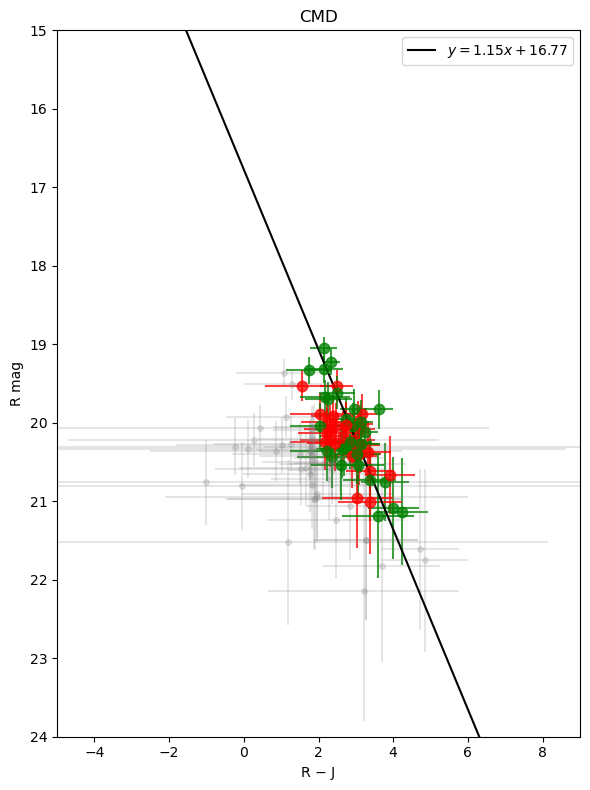

In [23]:
#Real best fit
from scipy.odr import ODR, Model, RealData

def line(B, x):
    return B[0] * x + B[1]

all_x = []
all_y = []
all_xerr = []
all_yerr = []

plt.figure(figsize=(6, 8))

for qnum, seg in color_df.groupby("Q"):

    x = seg["R_minus_J"].values
    y = seg["mag_shifted_R"].values
    yerr = seg["mag_shifted_err_R"].values
    xerr = np.sqrt(
        yerr**2 +
        seg["mag_shifted_err_J"].values**2
    )

    mask = xerr < 1

    xignore = x[~mask]
    yignore = y[~mask]
    xerrignore = xerr[~mask]
    yerrignore = yerr[~mask]

    x = x[mask]
    y = y[mask]
    xerr = xerr[mask]
    yerr = yerr[mask]

    lab = seg["follow_label"].iloc[0]

    all_x.extend(x)
    all_y.extend(y)
    all_xerr.extend(xerr)
    all_yerr.extend(yerr)

    plt.errorbar(
        x, y,
        xerr=xerr,
        yerr=yerr,
        fmt='.',
        color=label_colors[lab],
        alpha=0.75,
        markersize=15
    )

    plt.errorbar(
        xignore, yignore,
        xerr=xerrignore,
        yerr=yerrignore,
        fmt='.',
        color='gray',
        alpha=0.2,
        markersize=8
    )

# Convert to arrays
all_x = np.array(all_x)
all_y = np.array(all_y)
all_xerr = np.array(all_xerr)
all_yerr = np.array(all_yerr)

# ODR fit
model = Model(line)
data = RealData(
    all_x,
    all_y,
    sx=all_xerr,
    sy=all_yerr
)

odr = ODR(data, model, beta0=[-7/8, 18])
output = odr.run()

slope_best, intercept = output.beta

# Plot fit
xplot = np.linspace(-5, 9, 100)
yplot = line(output.beta, xplot)

plt.plot(
    xplot,
    yplot,
    'k-',
    label=f'$y={slope_best:.2f}x+{intercept:.2f}$'
)

plt.xlim(-5, 9)
plt.ylim(24, 15)
plt.xlabel("R − J")
plt.ylabel("R mag")
plt.title("CMD")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
print("Slope:", slope_best)
print("Intercept:", intercept)
print("Parameter uncertainties:", output.sd_beta)

Slope: 1.1465918230243453
Intercept: 16.772944753200058
Parameter uncertainties: [0.1480984  0.41894287]


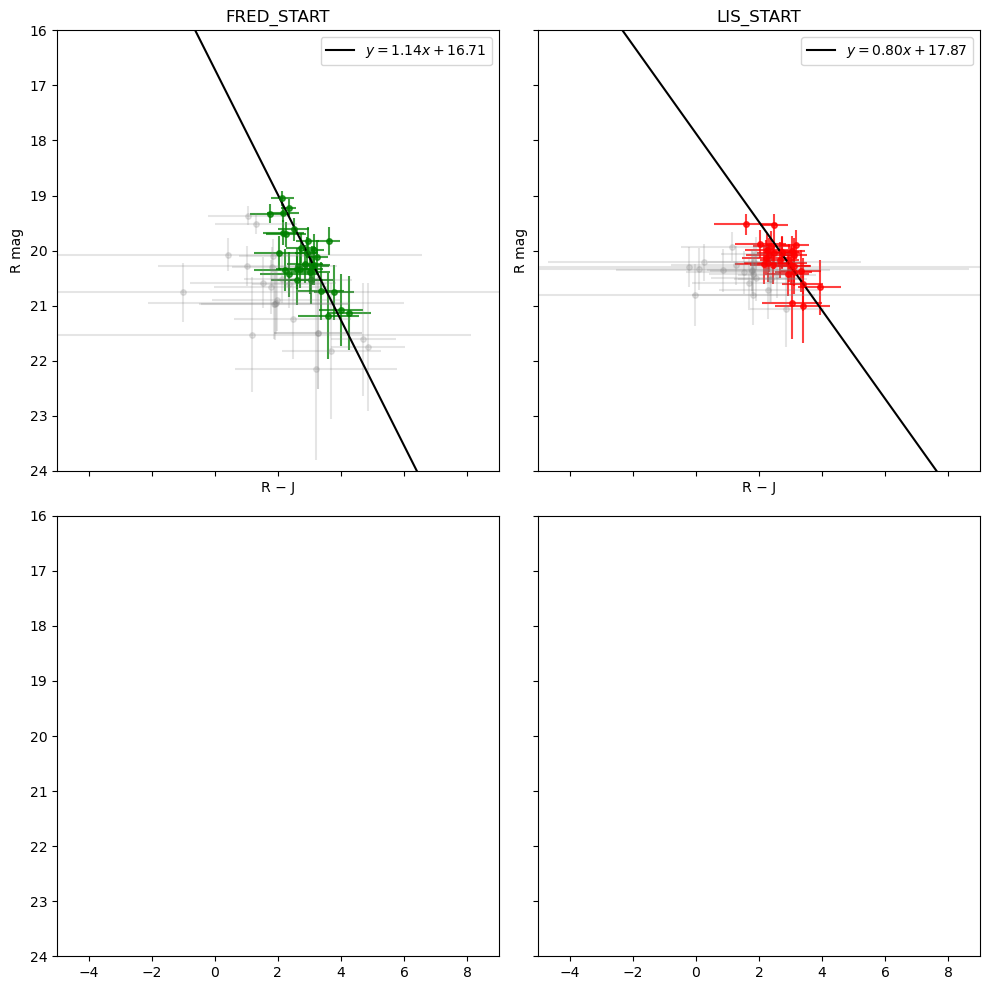

In [25]:
model = Model(line)

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

slopes_by_group = {}   # store slopes here

for ax, (lab, seg) in zip(axes, color_df.groupby("follow_label")):

    x = seg["R_minus_J"].to_numpy()
    y = seg["mag_shifted_R"].to_numpy()
    yerr = seg["mag_shifted_err_R"].to_numpy()
    xerr = np.sqrt(
        yerr**2 +
        seg["mag_shifted_err_J"].to_numpy()**2
    )

    mask = (xerr < 1) & (x<6)

    xignore = x[~mask]
    yignore = y[~mask]
    yerrignore = yerr[~mask]
    xerrignore = xerr[~mask]

    x = x[mask]
    y = y[mask]
    xerr = xerr[mask]
    yerr = yerr[mask]

    # -------------------------
    # Plot data
    # -------------------------
    ax.errorbar(
        x, y,
        xerr=xerr,
        yerr=yerr,
        fmt='.',
        color=label_colors[lab],
        alpha=0.75,
        markersize=8
    )

    ax.errorbar(
        xignore, yignore,
        xerr=xerrignore,
        yerr=yerrignore,
        fmt='.',
        color='gray',
        alpha=0.2,
        markersize=8
    )

    # -------------------------
    # ODR fit
    # -------------------------
    data = RealData(x, y, sx=xerr, sy=yerr)
    odr = ODR(data, model, beta0=[-0.8, 18])
    output = odr.run()

    slope, intercept = output.beta
    slopes_by_group[lab] = slope   # store result

    # -------------------------
    # Plot fit
    # -------------------------
    xplot = np.linspace(-5, 9, 100)
    yplot = line(output.beta, xplot)

    ax.plot(
        xplot,
        yplot,
        'k-',
        label=f'$y={slope:.2f}x+{intercept:.2f}$'
    )

    ax.set_title(lab)
    ax.set_xlim(-5, 9)
    ax.set_ylim(24, 16)
    ax.set_xlabel("R − J")
    ax.set_ylabel("R mag")
    ax.legend()

plt.tight_layout()
plt.savefig('/home/kmc249/Downloads/quiescentCMDs.png', dpi=300)
plt.show()

In [26]:
# -------------------------
# print slopes cleanly
# -------------------------
print("Slopes by group:")
for k, v in slopes_by_group.items():
    print(f"{k}: {v:.4f}")

Slopes by group:
FRED_START: 1.1393
LIS_START: 0.8039


In [27]:
#monte carlo null test

Nsim = 10000
slopes = []

# Keep only the stars used in the real fit
Rerr = color_df["mag_shifted_err_R"].values
Jerr = color_df["mag_shifted_err_J"].values

mask = np.sqrt(Rerr**2 + Jerr**2) < 1

R = color_df["mag_shifted_R"].values[mask]
J = color_df["mag_shifted_J"].values[mask]
Rerr = Rerr[mask]
Jerr = Jerr[mask]

model = Model(line)

for i in range(Nsim):

    # Destroy the pairing between R and J
    '''
    perm = np.random.permutation(len(J))

    Jperm = J[perm]
    Jerrperm = Jerr[perm]
    '''
    n = len(J)
    shift = np.random.randint(0, n)
    
    Jperm = np.roll(J, shift)
    Jerrperm = np.roll(Jerr, shift)

    x = R - Jperm
    y = R

    xerr = np.sqrt(Rerr**2 + Jerrperm**2)
    yerr = Rerr

    data = RealData(
        x,
        y,
        sx=xerr,
        sy=yerr
    )

    odr = ODR(
        data,
        model,
        beta0=[slope_best, intercept]   # or [-0.8, 18]
    )

    output = odr.run()

    slopes.append(output.beta[0])

slopes = np.array(slopes)


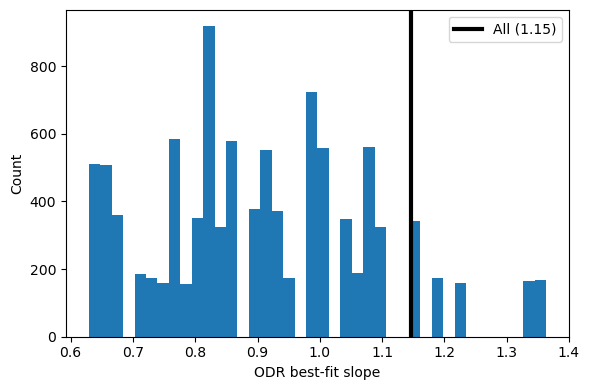

In [28]:
# Plot null distribution
plt.figure(figsize=(6,4))
plt.hist(slopes, bins=40)
plt.axvline(
    slope_best,
    color='k',
    lw=3,
    label=f'All ({slope_best:.2f})'
)
plt.xlabel("ODR best-fit slope")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# One-sided p-value
p = np.mean(slopes >= slope_best)

print(f"Observed slope = {slope_best:.3f}")
print(f"Null mean      = {slopes.mean():.3f}")
print(f"Null std       = {slopes.std():.3f}")
print(f"Monte Carlo p  = {p:.4g}")

Observed slope = 1.147
Null mean      = 0.906
Null std       = 0.172
Monte Carlo p  = 0.0669


In [30]:


def odr_fit(x, y, xerr, yerr, beta0=[-0.8, 18]):
    """Run ODR and return slope, intercept."""
    def line(B, x):
        return B[0]*x + B[1]

    model = Model(line)
    data = RealData(x, y, sx=xerr, sy=yerr)
    odr = ODR(data, model, beta0=beta0)
    out = odr.run()

    return out.beta[0], out.beta[1]


def simulate_slopes_odr(R, J, Rerr, Jerr, N=1000):
    """Monte Carlo null distribution for ONE subgroup."""
    
    slopes = []

    for _ in range(N):

        Jperm = np.random.permutation(J)
        Jerrperm = Jerr[np.random.permutation(len(Jerr))]

        x = R - Jperm
        y = R

        xerr = np.sqrt(Rerr**2 + Jerrperm**2)
        yerr = Rerr

        try:
            m, _ = odr_fit(x, y, xerr, yerr)
            slopes.append(m)
        except:
            continue

    return np.array(slopes)

In [31]:
results = {}

Nsim = 10000
model = Model(line)

for lab, seg in color_df.groupby("follow_label"):

    # -------------------------
    # Extract raw measurements
    # -------------------------
    R = seg["mag_shifted_R"].values
    J = seg["mag_shifted_J"].values

    Rerr = seg["mag_shifted_err_R"].values
    Jerr = seg["mag_shifted_err_J"].values

    # consistent mask (same idea as your original)
    mask = (np.sqrt(Rerr**2 + Jerr**2) < 1) & (R-J<6)

    R = R[mask]
    J = J[mask]
    Rerr = Rerr[mask]
    Jerr = Jerr[mask]

    slopes = []

    # -------------------------
    # Monte Carlo null (PER LABEL)
    # -------------------------
    for i in range(Nsim):

        # break pairing between R and J (key step from your working code)
        '''
        perm = np.random.permutation(len(J))

        Jperm = J[perm]
        Jerrperm = Jerr[perm]

        '''
        Jperm = np.random.choice(J, size=len(J), replace=True)
        Jerrperm = np.random.choice(Jerr, size=len(J), replace=True)
        
        '''
        n = len(J)
        shift = np.random.randint(0, n)
        
        Jperm = np.roll(J, shift)
        Jerrperm = np.roll(Jerr, shift)
        '''
        # construct color and magnitude
        x = R - Jperm
        y = R

        # consistent propagated errors (same as your working version)
        xerr = np.sqrt(Rerr**2 + Jerrperm**2)
        yerr = Rerr

        data = RealData(
            x,
            y,
            sx=xerr,
            sy=yerr
        )

        odr = ODR(
            data,
            model,
            beta0=[slope_best, intercept]  # keep your global prior
        )

        out = odr.run()
        slopes.append(out.beta[0])

    slopes = np.array(slopes)

    # -------------------------
    # observed fit (IMPORTANT: same construction)
    # -------------------------
    x_obs = R - J
    y_obs = R
    xerr_obs = np.sqrt(Rerr**2 + Jerr**2)
    yerr_obs = Rerr

    data_obs = RealData(x_obs, y_obs, sx=xerr_obs, sy=yerr_obs)
    odr_obs = ODR(data_obs, model, beta0=[slope_best, intercept])
    out_obs = odr_obs.run()

    slope_obs = out_obs.beta[0]
    intercept_obs = out_obs.beta[1]

    # -------------------------
    # p-value
    # -------------------------
    p = np.mean(slopes >= slope_obs)

    results[lab] = {
        "slope_obs": slope_obs,
        "intercept": intercept_obs,
        "slopes_null": slopes,
        "p_value": p
    }

    print(f"{lab}: slope={slope_obs:.3f}, p={p:.4g}, N={len(slopes)}")

FRED_START: slope=1.139, p=0.064, N=10000
LIS_START: slope=0.804, p=0.2741, N=10000


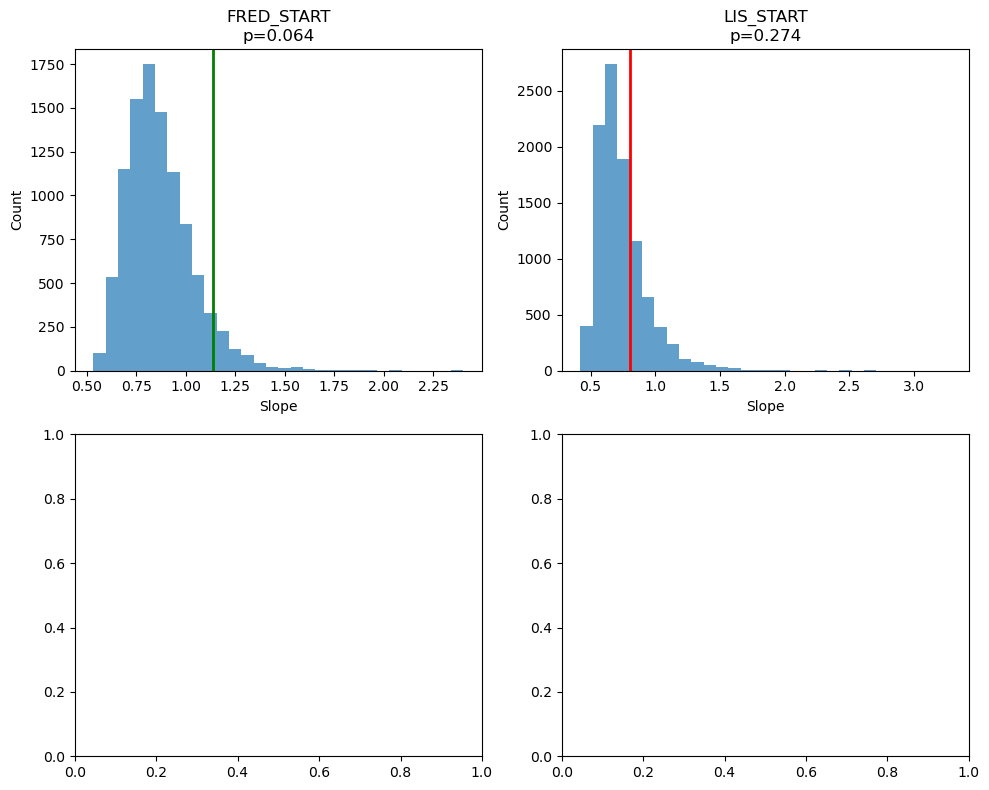

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (lab, res) in zip(axes, results.items()):

    slopes_null = res["slopes_null"]
    slopes_null = slopes_null[slopes_null<4]
        
    obs = res["slope_obs"]

    ax.hist(slopes_null, bins=30, alpha=0.7)
    ax.axvline(obs, color=label_colors[lab], lw=2)

    ax.set_title(f"{lab}\np={res['p_value']:.3g}")
    ax.set_xlabel("Slope")
    ax.set_ylabel("Count")
    

plt.tight_layout()
plt.savefig('/home/kmc249/Downloads/modeled_quiescentCMDs.png', dpi=300)
plt.show()

/tmp/ipykernel_1372345/270482073.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


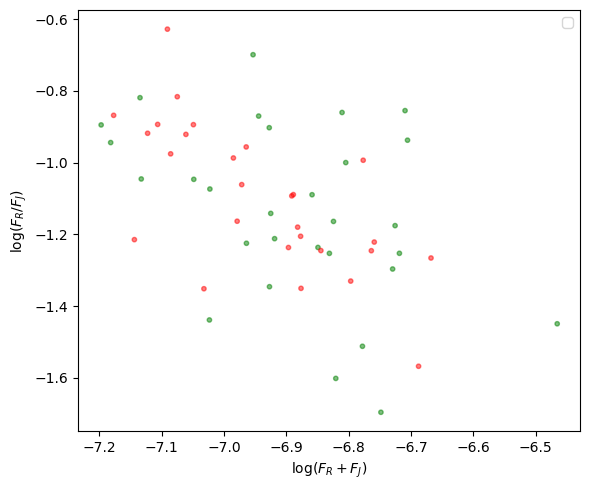

In [33]:
# ----------------------------
# 1. Convert mag -> flux
# ----------------------------
def mag_to_flux(m):
    return 10**(-0.4 * m)

def magerr_to_fluxerr(m, merr):
    F = mag_to_flux(m)
    return 0.4 * np.log(10) * F * merr

R_mag = color_df["mag_shifted_R"].values
J_mag = color_df["mag_shifted_J"].values
Rerr_mag = color_df["mag_shifted_err_R"].values
Jerr_mag = color_df["mag_shifted_err_J"].values
follow_labels=color_df["follow_label"]


mask = np.sqrt(Rerr_mag**2 + Jerr_mag**2) < 1

R_mag = R_mag[mask]
J_mag = J_mag[mask]
Rerr_mag = Rerr_mag[mask]
Jerr_mag = Jerr_mag[mask]
colorlist = np.array([label_colors[lab] for lab in follow_labels])[mask]

FR = mag_to_flux(R_mag)
FJ = mag_to_flux(J_mag)

FR_err = magerr_to_fluxerr(R_mag, Rerr_mag)
FJ_err = magerr_to_fluxerr(J_mag, Jerr_mag)

# ----------------------------
# 2. Derived quantities + errors
# ----------------------------

# color: log(FR/FJ)
color = np.log10(FR / FJ)
color_err = (1 / np.log(10)) * np.sqrt((FR_err / FR)**2 + (FJ_err / FJ)**2)

# total flux
total = FR + FJ
total_err = np.sqrt(FR_err**2 + FJ_err**2)

# log total
log_total = np.log10(total)
log_total_err = total_err / (total * np.log(10))

# ----------------------------
# 3. ODR fit: color vs log(total)
# ----------------------------
def line(B, x):
    return B[0] * x + B[1]

model = Model(line)
data = RealData(log_total, color,
                sx=log_total_err,
                sy=color_err)

odr = ODR(data, model, beta0=[0.0, 0.0])
out = odr.run()

slope, intercept = out.beta

# line for plotting
xline = np.linspace(log_total.min(), log_total.max(), 100)
yline = slope * xline + intercept

# ----------------------------
# 4. Plot
# ----------------------------
plt.figure(figsize=(6,5))

# scatter (cleaner than full errorbars for large N)
plt.scatter(log_total, color, s=10, alpha=0.5, c=colorlist)

# optional: show a subset of errorbars (avoids clutter)
'''
idx = np.arange(0, len(log_total), max(1, len(log_total)//30))
plt.errorbar(log_total[idx], color[idx],
             xerr=log_total_err[idx],
             yerr=color_err[idx],
             fmt='none', alpha=0.4)
'''
'''
plt.plot(xline, yline, 'r', lw=2,
         label=f'slope = {slope:.2f}')
'''
plt.xlabel(r'$\log(F_R + F_J)$')
plt.ylabel(r'$\log(F_R / F_J)$')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
print(np.mean(FR), np.std(FR))
print(np.mean(FJ), np.std(FJ))

expected = np.cov(log_total, color, bias=True)[0,1] / np.var(log_total)

print(expected)

9.341492588251038e-09 4.158415002081945e-09
1.2103880574436746e-07 4.848261386658227e-08
-0.7678636263382518


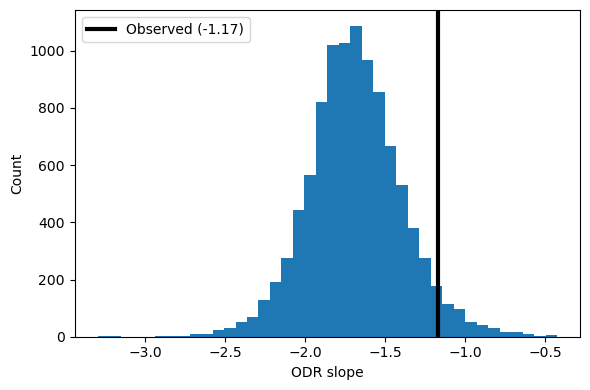

Observed slope = -1.1717
Null mean      = -1.6881
Null std       = 0.2956
Monte Carlo p  = 0.0443


In [35]:
# -----------------------------------------
# Monte Carlo permutation test
# H0: FR and FJ are unrelated
# -----------------------------------------

Nsim = 10000
null_slopes = []

for i in range(Nsim):

    # destroy pairing between FR and FJ
    perm = np.random.permutation(len(FJ))

    FJ_perm = FJ[perm]
    FJerr_perm = FJ_err[perm]

    # recompute derived quantities
    color_mc = np.log10(FR / FJ_perm)

    color_err_mc = (1 / np.log(10)) * np.sqrt(
        (FR_err / FR)**2 +
        (FJerr_perm / FJ_perm)**2
    )

    total_mc = FR + FJ_perm
    total_err_mc = np.sqrt(FR_err**2 + FJerr_perm**2)

    log_total_mc = np.log10(total_mc)
    log_total_err_mc = total_err_mc / (total_mc * np.log(10))

    # ODR fit
    data_mc = RealData(
        log_total_mc,
        color_mc,
        sx=log_total_err_mc,
        sy=color_err_mc
    )

    odr_mc = ODR(
        data_mc,
        model,
        beta0=[slope, intercept]
    )

    out_mc = odr_mc.run()

    null_slopes.append(out_mc.beta[0])

null_slopes = np.array(null_slopes)

# -----------------------------------------
# Plot null distribution
# -----------------------------------------

plt.figure(figsize=(6,4))

plt.hist(null_slopes, bins=40)

plt.axvline(
    slope,
    color='k',
    lw=3,
    label=f"Observed ({slope:.2f})"
)

plt.xlabel("ODR slope")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------
# p-value
# -----------------------------------------

if slope >= null_slopes.mean():
    p = np.mean(null_slopes >= slope)
else:
    p = np.mean(null_slopes <= slope)

print(f"Observed slope = {slope:.4f}")
print(f"Null mean      = {null_slopes.mean():.4f}")
print(f"Null std       = {null_slopes.std():.4f}")
print(f"Monte Carlo p  = {p:.4g}")

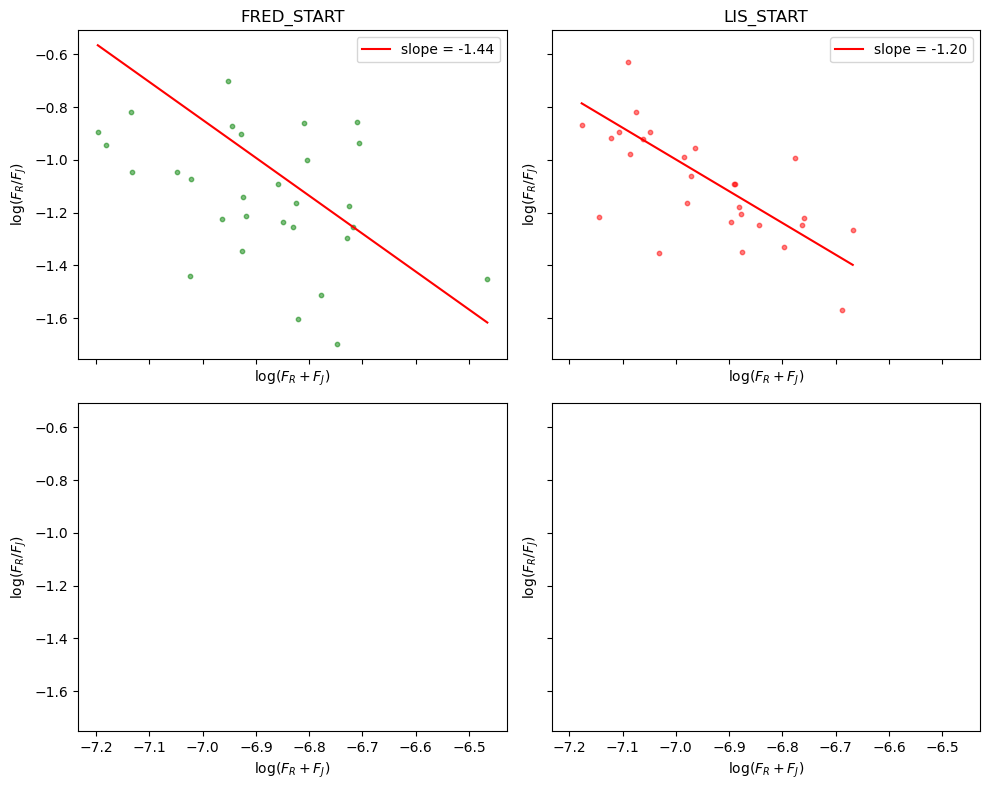

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData

# ----------------------------
# helper functions
# ----------------------------
def mag_to_flux(m):
    return 10**(-0.4 * m)

def magerr_to_fluxerr(m, merr):
    F = mag_to_flux(m)
    return 0.4 * np.log(10) * F * merr

def line(B, x):
    return B[0] * x + B[1]

model = Model(line)

# ----------------------------
# setup
# ----------------------------
groups = list(color_df.groupby("follow_label"))

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

# optional: store slopes
slopes = {}

# ----------------------------
# loop
# ----------------------------
for ax, (lab, seg) in zip(axes, groups):

    R_mag = seg["mag_shifted_R"].values
    J_mag = seg["mag_shifted_J"].values
    Rerr_mag = seg["mag_shifted_err_R"].values
    Jerr_mag = seg["mag_shifted_err_J"].values

    # mask
    mask = np.sqrt(Rerr_mag**2 + Jerr_mag**2) < 1

    R_mag = R_mag[mask]
    J_mag = J_mag[mask]
    Rerr_mag = Rerr_mag[mask]
    Jerr_mag = Jerr_mag[mask]

    # flux
    FR = mag_to_flux(R_mag)
    FJ = mag_to_flux(J_mag)

    FR_err = magerr_to_fluxerr(R_mag, Rerr_mag)
    FJ_err = magerr_to_fluxerr(J_mag, Jerr_mag)

    # derived quantities
    color = np.log10(FR / (FJ))
    color_err = (1 / np.log(10)) * np.sqrt((FR_err / FR)**2 + (FJ_err / FJ)**2)

    total = FR + FJ
    total_err = np.sqrt(FR_err**2 + FJ_err**2)

    log_total = np.log10(total)
    log_total_err = total_err / (total * np.log(10))
    

    # ----------------------------
    # ODR fit
    # ----------------------------
    data = RealData(log_total, color,
                    sx=log_total_err,
                    sy=color_err)

    m, b = np.polyfit(log_total, color, 1)

    if lab == "ONLY_FRED":
        slope, intercept = m, b
    else:
        odr = ODR(data, model, beta0=[m, b])
        out = odr.run()

        slope, intercept = out.beta
    slopes[lab] = slope

    xline = np.linspace(log_total.min(), log_total.max(), 100)
    yline = slope * xline + intercept

    # ----------------------------
    # plot
    # ----------------------------
    ax.scatter(log_total, color, s=10, alpha=0.5,
               color=label_colors[lab])

    ax.plot(xline, yline, 'r',
            label=f"slope = {slope:.2f}")

    ax.set_title(lab)
    ax.legend()
    
    #print(lab, np.min(FJ), np.max(FJ))
    #print(lab, np.min(log_total), np.max(log_total))
    #print(lab, len(log_total))
# shared labels
for ax in axes:
    ax.set_xlabel(r'$\log(F_R + F_J)$')
    ax.set_ylabel(r'$\log(F_R / F_J)$')

plt.tight_layout()
plt.show()



#print(slopes)

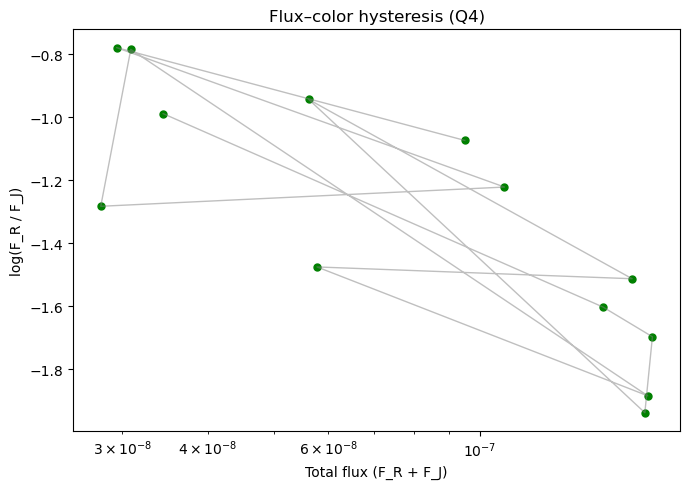

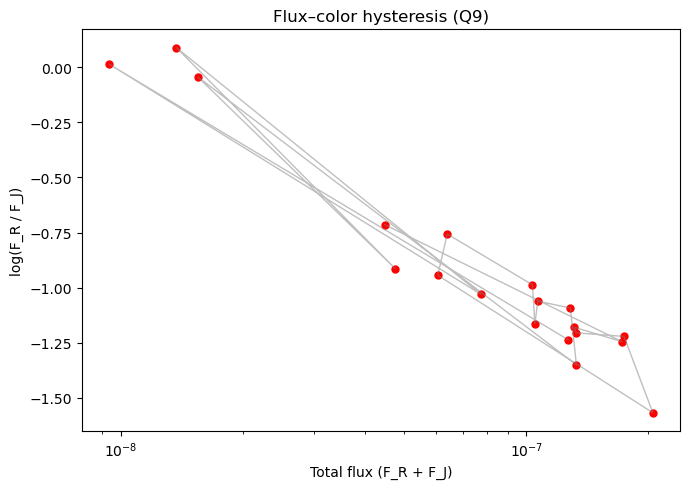

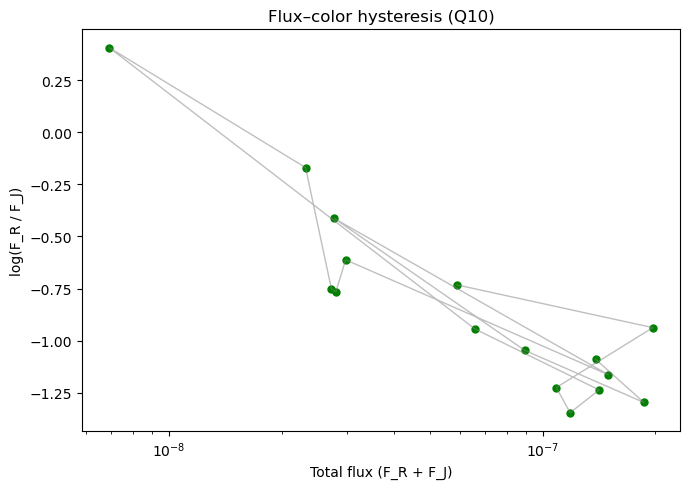

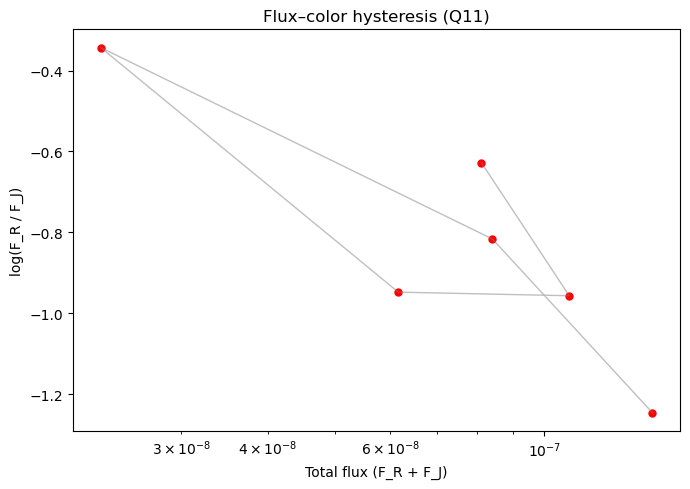

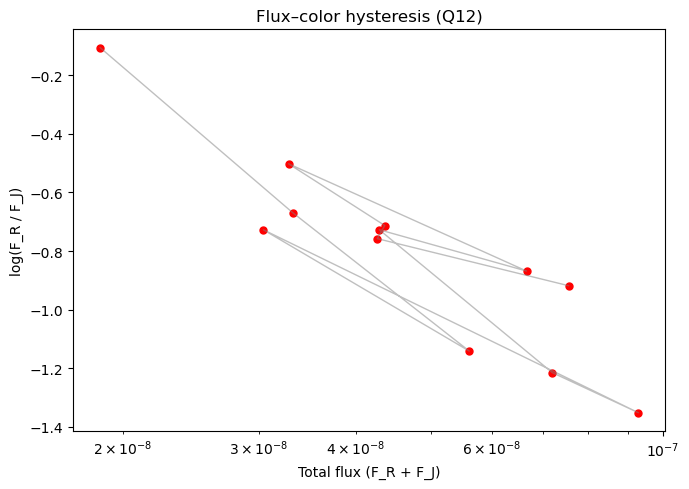

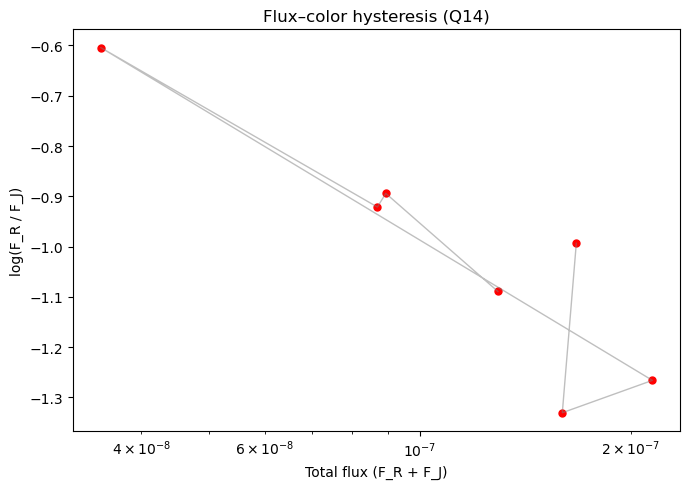

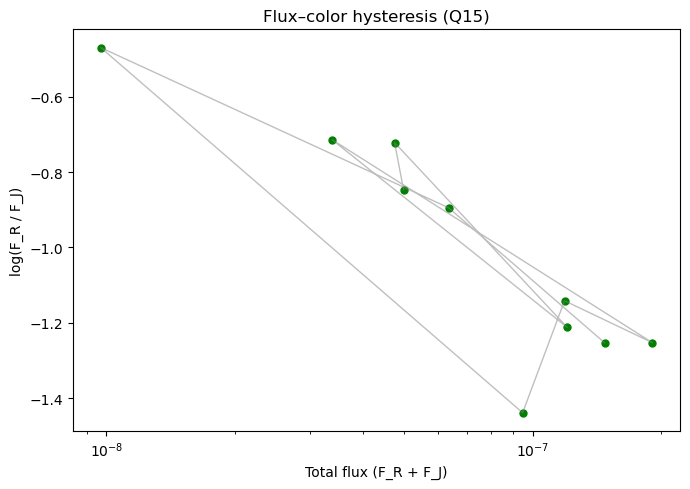

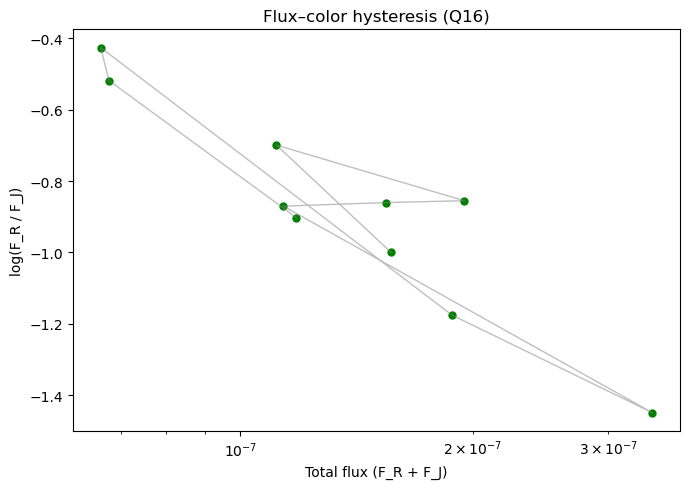

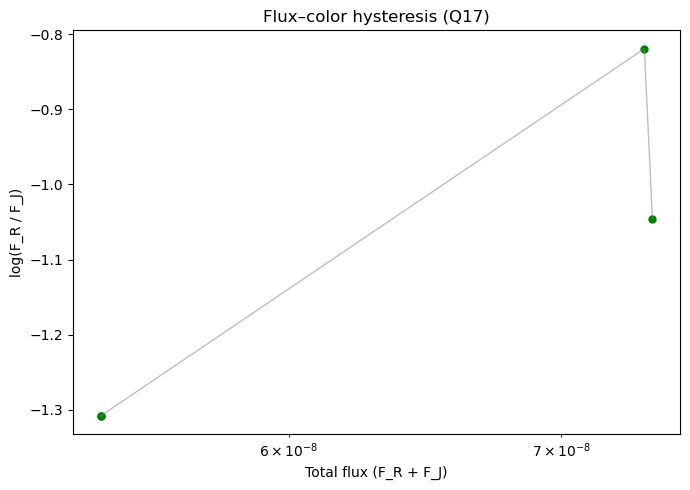

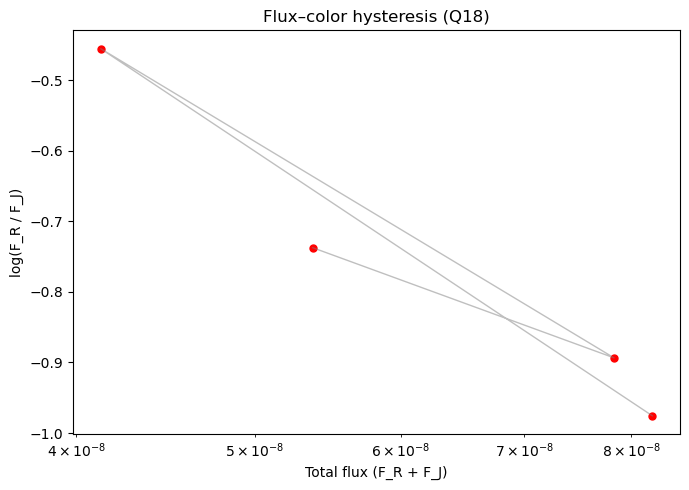

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def mag_to_flux(m):
    return 10**(-0.4 * m)

# loop over quiescent segments
for qnum, seg in color_df.groupby("Q"):

    R = seg["mag_shifted_R"].values
    J = seg["mag_shifted_J"].values

    FR = mag_to_flux(R)
    FJ = mag_to_flux(J)

    flux = FR + FJ
    color = np.log10(FR / FJ)

    time = seg["MJD_R"].values

    idx = np.argsort(time)

    plt.figure(figsize=(7,5))

    # trajectory (time-ordered path)
    plt.plot(flux[idx], color[idx],
             color='gray', alpha=0.5, linewidth=1)
    lab = seg["follow_label"].iloc[0]
    # points colored by time
    sc = plt.scatter(flux[idx], color[idx],c=label_colors[lab],
                     s=25)

    plt.xlabel("Total flux (F_R + F_J)")
    plt.ylabel("log(F_R / F_J)")
    plt.title(f"Flux–color hysteresis (Q{qnum})")

    plt.xscale("log")
    plt.tight_layout()
    plt.show()

In [38]:
testR=np.random.normal(loc=9.63155834619497e-09, scale=9.434610773877621e-09, size=1000)
testJ=np.random.normal(loc=1.306980178314502e-07 , scale=1.6491524096815772e-07, size=1000)

-1.2037538921934154


/tmp/ipykernel_1372345/3860296167.py:1: RuntimeWarning: invalid value encountered in log10
  testx=np.log10(testR+testJ)
/tmp/ipykernel_1372345/3860296167.py:2: RuntimeWarning: invalid value encountered in log
  testy=np.log(testR/testJ)


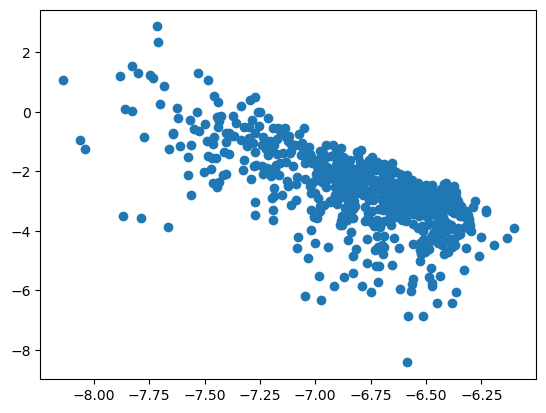

In [39]:
testx=np.log10(testR+testJ)
testy=np.log(testR/testJ)
odr = ODR(data, model, beta0=[m, b])
out = odr.run()

slope, intercept = out.beta
print(slope)

plt.scatter(testx, testy)